In [1]:
# Block 1 Installing all required libraries for the project

!pip install transformers torch datasets scikit-learn pandas numpy matplotlib seaborn
!pip install bertopic sentence-transformers umap-learn hdbscan
!pip install kaggle
!pip install streamlit pyngrok
!pip install shap plotly
!pip install langdetect
!pip install wordcloud
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 6.3 MB/s eta 0:00:000:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 8.2 MB/s eta 0:00:008.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 8.7 MB/s eta 0:00:009.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 7.8 MB/s eta 0:00:007.9 MB/s eta 0:00:01
  Attempting uninstall: regex
    Found existing installation: regex 2024.11.6
    Uninstalling regex-2024.11.6:
      Successfully uninstalled regex-2024.11.6
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.0
    Uninstalling pyarrow-19.0.0:
      Successfully uninstalled pyarrow-19.0.0
  Attempting uninstall: dill━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/14 [pyarrow]
    Found existing installation: dill 0.3.8114m╸━━━━━━━━

In [2]:
# Block 2 Setting up Kaggle and downloading the Steam dataset

import os
import json

kaggle_credentials = {
    "username": "amish111",
    "key": "04ff704c8ae786fb05d89f0f237c3f1c"
}

os.makedirs(os.path.expanduser('~/.config/kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.config/kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod(os.path.expanduser('~/.config/kaggle/kaggle.json'), 0o600)

!kaggle datasets download -d andrewmvd/steam-reviews
!unzip -q steam-reviews.zip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/steam-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100%|████████████████████████████████████████| 685M/685M [01:41<00:00, 7.07MB/s]



In [1]:
# Block 3 Loading the full dataset and doing initial exploration

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# loading all 6.4 million records
df = pd.read_csv('dataset.csv', low_memory=False)

print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst few rows:")
df.head()

Dataset shape: (6417106, 5)

Column names: ['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']

Data types:
 app_id           int64
app_name        object
review_text     object
review_score     int64
review_votes     int64
dtype: object

Missing values:
 app_id               0
app_name        183234
review_text       7305
review_score         0
review_votes         0
dtype: int64

First few rows:


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1


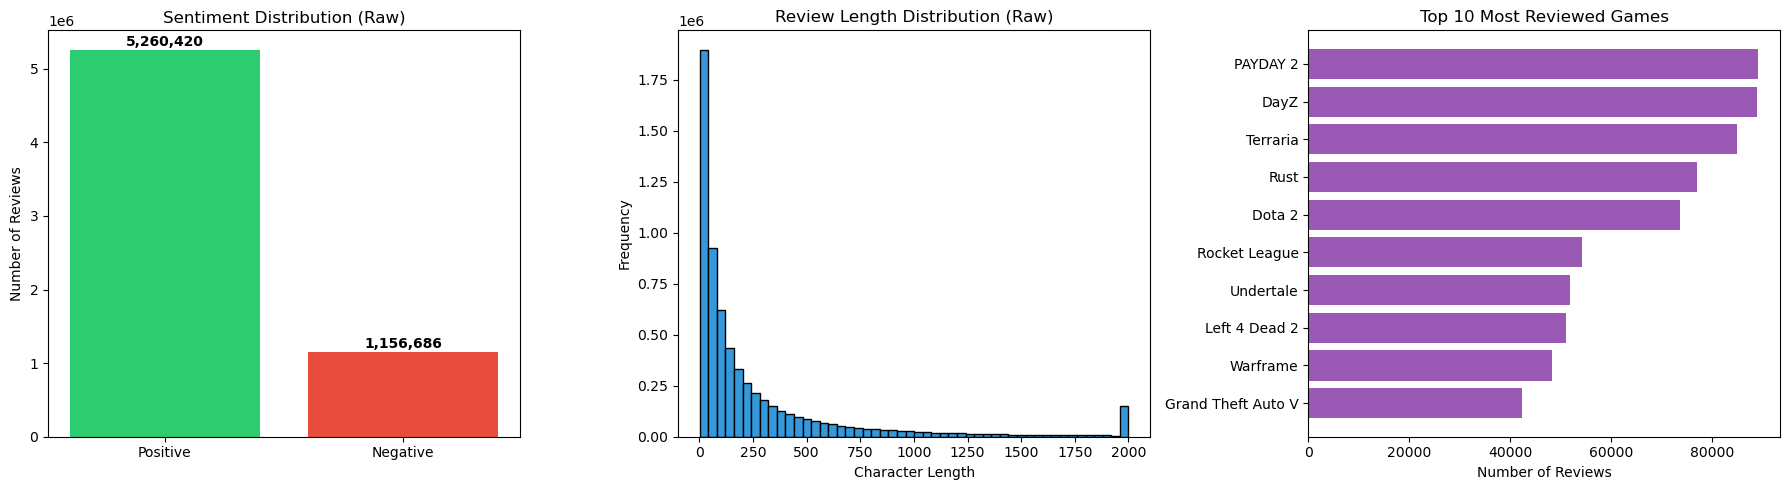


Sentiment breakdown:
review_score
Positive    5260420
Negative    1156686
Name: count, dtype: int64

Average review length: 304 characters
Median review length: 104 characters


In [3]:
# Block 4 Visualising the raw dataset to understand what we are working with

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# sentiment distribution
sentiment_counts = df['review_score'].map({1: 'Positive', -1: 'Negative'}).value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Sentiment Distribution (Raw)')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50000, f'{v:,}', ha='center', fontweight='bold')

# review length distribution
df['review_length'] = df['review_text'].astype(str).apply(len)
axes[1].hist(df['review_length'].clip(upper=2000), bins=50, color='#3498db', edgecolor='black')
axes[1].set_title('Review Length Distribution (Raw)')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')

# top 10 most reviewed games
top_games = df['app_name'].value_counts().head(10)
axes[2].barh(top_games.index[::-1], top_games.values[::-1], color='#9b59b6')
axes[2].set_title('Top 10 Most Reviewed Games')
axes[2].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.savefig('raw_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSentiment breakdown:")
print(sentiment_counts)
print(f"\nAverage review length: {df['review_length'].mean():.0f} characters")
print(f"Median review length: {df['review_length'].median():.0f} characters")

In [4]:
# Block 5 Cleaning the full 6.4 million records

import re
from langdetect import detect, LangDetectException

print(f"Starting shape: {df.shape}")

# drop rows where review_text or app_name is missing
df.dropna(subset=['review_text', 'app_name'], inplace=True)
print(f"After dropping nulls: {df.shape}")

# drop exact duplicates based on review text
df.drop_duplicates(subset=['review_text'], inplace=True)
print(f"After removing duplicates: {df.shape}")

# clean the review text
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)           # remove html tags
    text = re.sub(r'http\S+|www\S+', ' ', text)  # remove urls
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)   # remove non ascii characters
    text = re.sub(r'\s+', ' ', text)              # normalize whitespace
    return text.strip()

df['review_text'] = df['review_text'].apply(clean_text)

# remove reviews that are too short to carry any meaningful information
df = df[df['review_text'].str.len() >= 50]
print(f"After removing short reviews: {df.shape}")

# map review score to readable sentiment labels
df['sentiment'] = df['review_score'].map({1: 'positive', -1: 'negative'})

print(f"\nFinal cleaned shape: {df.shape}")
print(f"\nSentiment distribution after cleaning:")
print(df['sentiment'].value_counts())

Starting shape: (6417106, 6)
After dropping nulls: (6226728, 6)
After removing duplicates: (4344181, 6)
After removing short reviews: (3579046, 6)

Final cleaned shape: (3579046, 7)

Sentiment distribution after cleaning:
sentiment
positive    2899576
negative     679470
Name: count, dtype: int64


In [6]:
import sys
!{sys.executable} -m pip install wordcloud langdetect

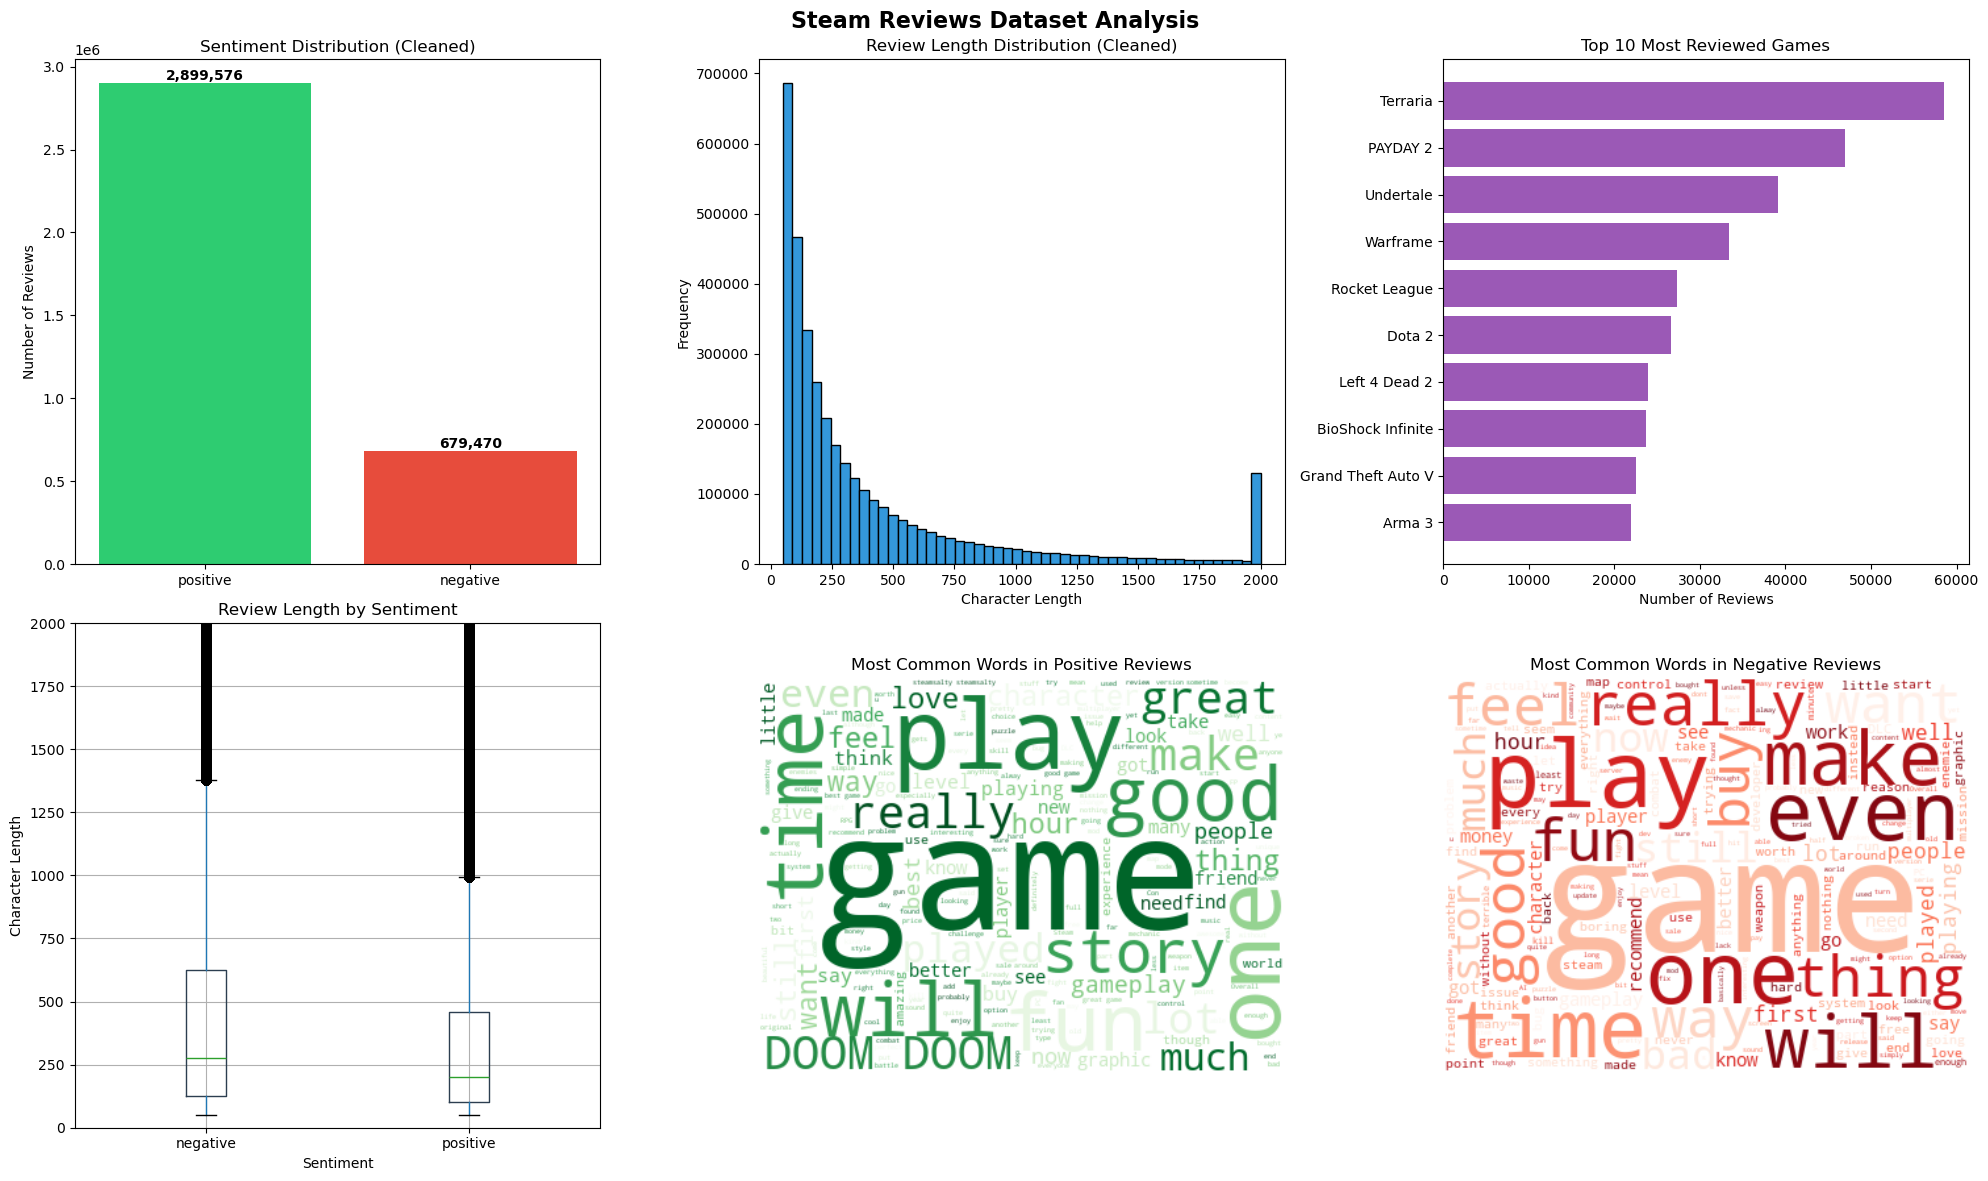

Cleaned dataset summary:
Total reviews: 3,579,046
Positive reviews: 2,899,576 (81.0%)
Negative reviews: 679,470 (19.0%)
Average review length: 450 characters
Unique games: 8,545


In [7]:
# Block 6 Exploring and visualising the cleaned dataset

from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# sentiment distribution after cleaning
sentiment_counts = df['sentiment'].value_counts()
axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Sentiment Distribution (Cleaned)')
axes[0, 0].set_ylabel('Number of Reviews')
for i, v in enumerate(sentiment_counts.values):
    axes[0, 0].text(i, v + 20000, f'{v:,}', ha='center', fontweight='bold')

# review length distribution after cleaning
df['review_length'] = df['review_text'].str.len()
axes[0, 1].hist(df['review_length'].clip(upper=2000), bins=50, color='#3498db', edgecolor='black')
axes[0, 1].set_title('Review Length Distribution (Cleaned)')
axes[0, 1].set_xlabel('Character Length')
axes[0, 1].set_ylabel('Frequency')

# top 10 most reviewed games
top_games = df['app_name'].value_counts().head(10)
axes[0, 2].barh(top_games.index[::-1], top_games.values[::-1], color='#9b59b6')
axes[0, 2].set_title('Top 10 Most Reviewed Games')
axes[0, 2].set_xlabel('Number of Reviews')

# review length by sentiment
df.boxplot(column='review_length', by='sentiment', ax=axes[1, 0], 
           boxprops=dict(color='#2c3e50'))
axes[1, 0].set_title('Review Length by Sentiment')
axes[1, 0].set_xlabel('Sentiment')
axes[1, 0].set_ylabel('Character Length')
axes[1, 0].set_ylim(0, 2000)

# wordcloud for positive reviews
positive_text = ' '.join(df[df['sentiment'] == 'positive']['review_text'].sample(10000, random_state=42))
wordcloud_pos = WordCloud(width=400, height=300, background_color='white', 
                          colormap='Greens').generate(positive_text)
axes[1, 1].imshow(wordcloud_pos, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('Most Common Words in Positive Reviews')

# wordcloud for negative reviews
negative_text = ' '.join(df[df['sentiment'] == 'negative']['review_text'].sample(10000, random_state=42))
wordcloud_neg = WordCloud(width=400, height=300, background_color='white', 
                          colormap='Reds').generate(negative_text)
axes[1, 2].imshow(wordcloud_neg, interpolation='bilinear')
axes[1, 2].axis('off')
axes[1, 2].set_title('Most Common Words in Negative Reviews')

plt.suptitle('Steam Reviews Dataset Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaned_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cleaned dataset summary:")
print(f"Total reviews: {len(df):,}")
print(f"Positive reviews: {sentiment_counts['positive']:,} ({sentiment_counts['positive']/len(df)*100:.1f}%)")
print(f"Negative reviews: {sentiment_counts['negative']:,} ({sentiment_counts['negative']/len(df)*100:.1f}%)")
print(f"Average review length: {df['review_length'].mean():.0f} characters")
print(f"Unique games: {df['app_name'].nunique():,}")

In [8]:
# Block 7 Saving the cleaned dataset locally

df.to_csv('steam_reviews_cleaned.csv', index=False)

print(f"Cleaned dataset saved successfully!")
print(f"File: steam_reviews_cleaned.csv")
print(f"Shape: {df.shape}")

Cleaned dataset saved successfully!
File: steam_reviews_cleaned.csv
Shape: (3579046, 7)


In [10]:
import sys
!{sys.executable} -m pip install bertopic sentence-transformers umap-learn hdbscan

  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached sentence_transformers-5.5.0-py3-none-any.whl.metadata (18 kB)
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached bertopic-0.17.4-py3-none-any.whl (154 kB)
Using cached sentence_transformers-5.5.0-py3-none-any.whl (588 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.4 MB/s  0:00:009.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 7.7 MB/s  0:00:04 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.6 MB/s  0:00:006.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 7.2 MB/s  0:00:017.3 MB/s eta 0:00:01:01
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [bertopic];237m━━━━ 8/9 [bertopic]rmers]


In [12]:
import sys
!{sys.executable} -m pip install tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.2 MB/s  0:00:00m 5.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 7.1 MB/s  0:00:31 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.0 MB/s  0:00:00m 9.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 7.6 MB/s  0:00:03a 0:00:01m eta 0:00:01
  Attempting uninstall: flatbuffers━━━━━━━━━━━━━━━━━━━ 0/6 [libclang]
    Found existing installation: flatbuffers 24.3.250m 0/6 [libclang]
    Uninstalling flatbuffers-24.3.25:━━━━━━━━━━━━━ 0/6 [libclang]
      Successfully uninstalled flatbuffers-24.3.25 0/6 [libclang]
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━ 0/6 [libclang]
    Found existing installation: protobuf 5.29.3━━ 0/6 [libclang]
    Uninstalling protobuf-5.29.3:━━━━━━━━━━━━━━━━━ 0/6 [libclang]
      Successfully uninstalled protobuf-5.29.3━━━━ 0/6 [libclang]
  Attempting uninstall: keras━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [protobuf]
    

In [1]:
# kernel was restarted to resolve conflicts so reloading the dataset again
import pandas as pd
df = pd.read_csv('steam_reviews_cleaned.csv')
print(df.shape)

(3579046, 7)


In [2]:
# Block 8 Automated aspect extraction using spaCy NER

import sys
!{sys.executable} -m pip install spacy
!{sys.executable} -m spacy download en_core_web_sm

import spacy
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import gc

# reload data after kernel restart
df = pd.read_csv('steam_reviews_cleaned.csv')
gc.collect()

nlp = spacy.load('en_core_web_sm')

print("Extracting aspects using NER and noun chunks...")

def extract_aspects(text):
    doc = nlp(str(text)[:500])  # limit to 500 chars for speed
    aspects = []
    
    # extract named entities
    for ent in doc.ents:
        if ent.label_ in ['PRODUCT', 'ORG', 'WORK_OF_ART', 'EVENT']:
            aspects.append(ent.text.lower())
    
    # extract noun chunks as additional aspects
    for chunk in doc.noun_chunks:
        if len(chunk.text.split()) <= 3:  # keep only short meaningful phrases
            aspects.append(chunk.text.lower())
    
    return aspects

# run on sample first to see what aspects are discovered
print("Running on 50,000 sample to discover aspects...")
sample_df = df.sample(n=50000, random_state=42)
sample_df['aspects'] = sample_df['review_text'].apply(extract_aspects)

# flatten all aspects and count frequencies
all_aspects = [aspect for aspects in sample_df['aspects'] for aspect in aspects]
aspect_counts = Counter(all_aspects)

print(f"\nTotal unique aspects found: {len(aspect_counts):,}")
print("\nTop 30 most common aspects:")
for aspect, count in aspect_counts.most_common(30):
    print(f"  {aspect}: {count:,}")

  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 6.9 MB/s  0:00:008.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.5/657.5 kB 8.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.1/812.1 kB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.6 MB/s  0:00:00
Using cached typer-0.25.1-py3-none-any.whl (58 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [spacy]8;5;237m━━ 17/18 [spacy]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 8.0 MB/s  0:00:017.9 MB/s eta 0:00:0101
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Extracting aspects using NER and noun chunks...
Running on 50,000 sample to discover aspects...

Total unique aspects found: 135,463

Top 30 most common 

In [4]:
# Block 9 Filtering aspects automatically using spaCy POS tags

from collections import Counter
from tqdm import tqdm
import pandas as pd

def extract_aspects_clean(text):
    doc = nlp(str(text)[:500])
    aspects = []
    
    for chunk in doc.noun_chunks:
        root = chunk.root
        if root.pos_ in ['NOUN', 'PROPN'] and not root.is_stop and len(chunk.text.split()) <= 3:
            aspects.append(chunk.text.lower().strip())
    
    for ent in doc.ents:
        if ent.label_ in ['PRODUCT', 'ORG', 'WORK_OF_ART', 'EVENT']:
            aspects.append(ent.text.lower().strip())
    
    return aspects

print("Re-extracting aspects with proper POS filtering...")
tqdm.pandas(desc="Extracting aspects")
sample_df['aspects'] = sample_df['review_text'].progress_apply(extract_aspects_clean)

all_aspects = [a for aspects in sample_df['aspects'] for a in aspects]
aspect_counts = Counter(all_aspects)

print(f"\nTotal unique aspects found: {len(aspect_counts):,}")
print("\nTop 50 aspects discovered:")
for aspect, count in aspect_counts.most_common(50):
    print(f"  {aspect}: {count:,}")

Re-extracting aspects with proper POS filtering...


Extracting aspects: 100%|█████████████████| 50000/50000 [10:11<00:00, 81.82it/s]


Total unique aspects found: 133,128

Top 50 aspects discovered:
  this game: 22,709
  the game: 12,920
  a game: 2,529
  the story: 2,348
  a lot: 2,307
  game: 2,201
  fun: 2,004
  people: 1,792
  steam: 1,162
  time: 1,160
  the gameplay: 1,150
  games: 1,133
  friends: 1,124
  dlc: 1,111
  gameplay: 1,086
  rpg: 1,000
  great game: 954
  lots: 906
  things: 905
  the graphics: 893
  sale: 876
  hours: 863
  fps: 821
  the end: 685
  a great game: 679
  -: 670
  money: 661
  the world: 647
  graphics: 638
  story: 619
  the time: 604
  multiplayer: 592
  times: 545
  the way: 531
  the characters: 529
  the music: 517
  amp: 514
  combat: 506
  alot: 498
  the fact: 470
  my opinion: 465
  pros: 465
  the best games: 463
  pc: 458
  a good game: 452
  characters: 449
  enemies: 447
  the controls: 445
  the series: 438
  weapons: 437


In [5]:
# Block 10 Mapping the top discovered aspects into final aspect categories

# get top 500 most frequent aspects
top_aspects = dict(aspect_counts.most_common(500))

# filter out aspects with less than 200 mentions
top_aspects = {k: v for k, v in top_aspects.items() if v >= 200}

print(f"Meaningful aspects with 200+ mentions: {len(top_aspects)}")
print("\nFinal aspect list for the model:")
for aspect, count in sorted(top_aspects.items(), key=lambda x: x[1], reverse=True):
    print(f"  {aspect}: {count:,}")

# save aspect list for use in training
import json
with open('discovered_aspects.json', 'w') as f:
    json.dump(top_aspects, f)

print("\nAspect list saved to discovered_aspects.json")

Meaningful aspects with 200+ mentions: 131

Final aspect list for the model:
  this game: 22,709
  the game: 12,920
  a game: 2,529
  the story: 2,348
  a lot: 2,307
  game: 2,201
  fun: 2,004
  people: 1,792
  steam: 1,162
  time: 1,160
  the gameplay: 1,150
  games: 1,133
  friends: 1,124
  dlc: 1,111
  gameplay: 1,086
  rpg: 1,000
  great game: 954
  lots: 906
  things: 905
  the graphics: 893
  sale: 876
  hours: 863
  fps: 821
  the end: 685
  a great game: 679
  -: 670
  money: 661
  the world: 647
  graphics: 638
  story: 619
  the time: 604
  multiplayer: 592
  times: 545
  the way: 531
  the characters: 529
  the music: 517
  amp: 514
  combat: 506
  alot: 498
  the fact: 470
  my opinion: 465
  pros: 465
  the best games: 463
  pc: 458
  a good game: 452
  characters: 449
  enemies: 447
  the controls: 445
  the series: 438
  weapons: 437
  a fan: 431
  stuff: 421
  tons: 391
  this review: 388
  the combat: 380
  cons: 379
  music: 377
  love: 369
  the developers: 365
  bug

In [6]:
# Block 11 Automatically filtering generic aspects using TF-IDF scoring

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# fit tfidf on the sample reviews
print("Fitting TF-IDF to score aspect informativeness...")
vectorizer = TfidfVectorizer(ngram_range=(1, 3), min_df=50, max_df=0.3)
tfidf_matrix = vectorizer.fit_transform(sample_df['review_text'])

# get tfidf vocabulary and scores
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
tfidf_dict = dict(zip(feature_names, tfidf_scores))

# score each discovered aspect using tfidf
aspect_tfidf_scores = {}
for aspect in top_aspects:
    if aspect in tfidf_dict:
        aspect_tfidf_scores[aspect] = tfidf_dict[aspect]

# keep only aspects with meaningful tfidf scores
threshold = np.percentile(list(aspect_tfidf_scores.values()), 40)
final_aspects = {k: v for k, v in aspect_tfidf_scores.items() if v >= threshold}

print(f"\nFinal meaningful aspects after TF-IDF filtering: {len(final_aspects)}")
print("\nTop aspects:")
for aspect, score in sorted(final_aspects.items(), key=lambda x: x[1], reverse=True)[:50]:
    print(f"  {aspect}: TF-IDF score {score:.4f} | frequency: {top_aspects.get(aspect, 0):,}")

import json
with open('discovered_aspects.json', 'w') as f:
    json.dump(list(final_aspects.keys()), f)
print("\nFinal aspects saved!")

Fitting TF-IDF to score aspect informativeness...

Final meaningful aspects after TF-IDF filtering: 70

Top aspects:
  the game: TF-IDF score 0.0165 | frequency: 12,920
  fun: TF-IDF score 0.0153 | frequency: 2,004
  games: TF-IDF score 0.0118 | frequency: 1,133
  story: TF-IDF score 0.0106 | frequency: 619
  time: TF-IDF score 0.0105 | frequency: 1,160
  love: TF-IDF score 0.0082 | frequency: 369
  buy: TF-IDF score 0.0079 | frequency: 285
  gameplay: TF-IDF score 0.0076 | frequency: 1,086
  hours: TF-IDF score 0.0068 | frequency: 863
  graphics: TF-IDF score 0.0063 | frequency: 638
  awesome: TF-IDF score 0.0060 | frequency: 285
  people: TF-IDF score 0.0059 | frequency: 1,792
  great game: TF-IDF score 0.0057 | frequency: 954
  friends: TF-IDF score 0.0050 | frequency: 1,124
  money: TF-IDF score 0.0046 | frequency: 661
  the story: TF-IDF score 0.0046 | frequency: 2,348
  steam: TF-IDF score 0.0045 | frequency: 1,162
  good game: TF-IDF score 0.0042 | frequency: 303
  characters: T

In [7]:
# Block 12 Final automated aspect cleaning and grouping into categories

import json

# automatically filter using length and spacy pos validation
def is_valid_aspect(aspect):
    if len(aspect) <= 2:
        return False
    if len(aspect.split()) == 1 and len(aspect) <= 3:
        return False
    doc = nlp(aspect)
    # must contain at least one noun or proper noun
    has_noun = any(token.pos_ in ['NOUN', 'PROPN'] for token in doc)
    return has_noun

valid_aspects = {k: v for k, v in final_aspects.items() if is_valid_aspect(k)}

print(f"Final valid aspects: {len(valid_aspects)}")
print("\nFinal clean aspect list:")
for aspect, score in sorted(valid_aspects.items(), key=lambda x: x[1], reverse=True):
    print(f"  {aspect}: {score:.4f}")

with open('discovered_aspects.json', 'w') as f:
    json.dump(list(valid_aspects.keys()), f)

print("\nClean aspects saved to discovered_aspects.json!")

Final valid aspects: 57

Final clean aspect list:
  the game: 0.0165
  games: 0.0118
  story: 0.0106
  time: 0.0105
  love: 0.0082
  gameplay: 0.0076
  hours: 0.0068
  graphics: 0.0063
  people: 0.0059
  great game: 0.0057
  friends: 0.0050
  money: 0.0046
  the story: 0.0046
  steam: 0.0045
  good game: 0.0042
  characters: 0.0042
  combat: 0.0041
  things: 0.0041
  multiplayer: 0.0040
  life: 0.0039
  times: 0.0038
  music: 0.0037
  sale: 0.0032
  action: 0.0030
  players: 0.0030
  controls: 0.0029
  puzzles: 0.0028
  years: 0.0027
  bugs: 0.0027
  content: 0.0027
  weapons: 0.0027
  stuff: 0.0027
  lots: 0.0026
  space: 0.0025
  the gameplay: 0.0025
  enemies: 0.0024
  the time: 0.0021
  hell: 0.0021
  the graphics: 0.0021
  mods: 0.0020
  the end: 0.0019
  cons: 0.0019
  zombies: 0.0019
  missions: 0.0019
  pros: 0.0018
  amazing game: 0.0018
  alot: 0.0018
  awesome game: 0.0018
  guns: 0.0017
  items: 0.0017
  the world: 0.0017
  the way: 0.0016
  the price: 0.0015
  the music: 0

In [8]:
# Block 13 Applying discovered aspects to the full dataset

import json
import pandas as pd
from tqdm import tqdm

with open('discovered_aspects.json', 'r') as f:
    discovered_aspects = json.load(f)

print(f"Applying {len(discovered_aspects)} aspects to full dataset...")

def find_aspects_in_review(text):
    text = str(text).lower()
    found = []
    for aspect in discovered_aspects:
        if aspect in text:
            found.append(aspect)
    return found if found else None

tqdm.pandas(desc="Tagging aspects")
df['aspects_found'] = df['review_text'].progress_apply(find_aspects_in_review)

# keep only reviews that have at least one aspect
df_aspects = df[df['aspects_found'].notna()].copy()

print(f"\nReviews with at least one aspect: {len(df_aspects):,}")
print(f"Reviews without any aspect: {len(df) - len(df_aspects):,}")
print(f"\nSentiment distribution in aspect reviews:")
print(df_aspects['sentiment'].value_counts())

df_aspects.to_csv('steam_reviews_with_aspects.csv', index=False)
print("\nSaved to steam_reviews_with_aspects.csv")

Applying 57 aspects to full dataset...


Tagging aspects: 100%|█████████████| 3579046/3579046 [01:08<00:00, 51911.26it/s]



Reviews with at least one aspect: 2,856,389
Reviews without any aspect: 722,657

Sentiment distribution in aspect reviews:
sentiment
positive    2309912
negative     546477
Name: count, dtype: int64

Saved to steam_reviews_with_aspects.csv


In [9]:
# Block 14 Creating one row per review-aspect pair for model training

import pandas as pd
import ast

df_aspects = pd.read_csv('steam_reviews_with_aspects.csv')

# converting string representation of list back to actual list
df_aspects['aspects_found'] = df_aspects['aspects_found'].apply(ast.literal_eval)

# explode so each aspect gets its own row
df_exploded = df_aspects.explode('aspects_found').reset_index(drop=True)
df_exploded.rename(columns={'aspects_found': 'aspect'}, inplace=True)

print(f"Total review-aspect pairs: {len(df_exploded):,}")
print(f"\nSentiment distribution:")
print(df_exploded['sentiment'].value_counts())
print(f"\nTop 20 most common aspects:")
print(df_exploded['aspect'].value_counts().head(20))

df_exploded.to_csv('steam_reviews_exploded.csv', index=False)
print("\nSaved to steam_reviews_exploded.csv")

Total review-aspect pairs: 10,735,037

Sentiment distribution:
sentiment
positive    8610694
negative    2124343
Name: count, dtype: int64

Top 20 most common aspects:
aspect
the game      1022731
time           822118
games          665576
story          599918
love           424599
gameplay       387631
hours          344980
graphics       308451
people         301795
cons           290554
times          272730
the story      256686
things         232010
action         210545
money          198493
characters     195389
great game     194814
steam          193397
friends        177298
combat         175715
Name: count, dtype: int64

Saved to steam_reviews_exploded.csv


In [10]:
# Block 15 Filtering to only keep automatically discovered aspects

import pandas as pd
import json

df_exploded = pd.read_csv('steam_reviews_exploded.csv')

with open('discovered_aspects.json', 'r') as f:
    discovered_aspects = json.load(f)

# filter to only keep aspects that were automatically discovered
df_exploded = df_exploded[df_exploded['aspect'].isin(discovered_aspects)]

print(f"Total review-aspect pairs: {len(df_exploded):,}")
print(f"\nSentiment distribution:")
print(df_exploded['sentiment'].value_counts())
print(f"\nAspect distribution:")
print(df_exploded['aspect'].value_counts())

df_exploded.to_csv('steam_reviews_exploded.csv', index=False)
print("\nSaved!")

Total review-aspect pairs: 10,735,037

Sentiment distribution:
sentiment
positive    8610694
negative    2124343
Name: count, dtype: int64

Aspect distribution:
aspect
the game          1022731
time               822118
games              665576
story              599918
love               424599
gameplay           387631
hours              344980
graphics           308451
people             301795
cons               290554
times              272730
the story          256686
things             232010
action             210545
money              198493
characters         195389
great game         194814
steam              193397
friends            177298
combat             175715
music              162172
sale               152523
life               148843
good game          140004
multiplayer        134256
the end            131099
players            126261
weapons            125328
the gameplay       121150
controls           119623
enemies            114704
years              111860


In [11]:
# Block 16 Stratified train test split

import pandas as pd
from sklearn.model_selection import train_test_split

df_exploded = pd.read_csv('steam_reviews_exploded.csv')

# encode sentiment as numeric
df_exploded['label'] = df_exploded['sentiment'].map({'positive': 1, 'negative': 0})

# stratified split keeping sentiment ratio consistent
train_df, test_df = train_test_split(
    df_exploded,
    test_size=0.2,
    random_state=42,
    stratify=df_exploded['label']
)

print(f"Training set: {len(train_df):,}")
print(f"Test set: {len(test_df):,}")
print(f"\nTraining sentiment distribution:")
print(train_df['label'].value_counts())
print(f"\nTest sentiment distribution:")
print(test_df['label'].value_counts())

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)
print("\nTrain and test sets saved!")

Training set: 8,588,029
Test set: 2,147,008

Training sentiment distribution:
label
1    6888555
0    1699474
Name: count, dtype: int64

Test sentiment distribution:
label
1    1722139
0     424869
Name: count, dtype: int64

Train and test sets saved!


In [8]:
# Block 17 BERT training on 200k samples

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, cohen_kappa_score
import warnings
import os
import json
import time
warnings.filterwarnings('ignore')

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class SteamReviewDataset(Dataset):
    def __init__(self, texts, aspects, labels, tokenizer, max_len=128):
        self.texts = texts
        self.aspects = aspects
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = f"[ASPECT] {self.aspects[idx]} [REVIEW] {self.texts[idx]}"
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Step 1/6 Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print(f"Train CSV loaded: {len(train_df):,} rows")
print(f"Test CSV loaded: {len(test_df):,} rows")

print("\nStep 2/6 Creating stratified samples...")
train_sample, _ = train_test_split(
    train_df,
    train_size=200000,
    random_state=42,
    stratify=train_df['label']
)

test_sample, _ = train_test_split(
    test_df,
    train_size=40000,
    random_state=42,
    stratify=test_df['label']
)

print(f"Training samples: {len(train_sample):,}")
print(f"Test samples: {len(test_sample):,}")
print(f"Training sentiment distribution:")
print(train_sample['label'].value_counts())

class_counts = train_sample['label'].value_counts().sort_index()
total = len(train_sample)
class_weights = torch.tensor(
    [total / (2 * class_counts[i]) for i in range(2)],
    dtype=torch.float
).to(device)
print(f"Class weights: {class_weights}")

print("\nStep 3/6 Loading tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("Tokenizer loaded!")

print("\nStep 4/6 Tokenizing and creating datasets...")
train_dataset = SteamReviewDataset(
    train_sample['review_text'].tolist(),
    train_sample['aspect'].tolist(),
    train_sample['label'].tolist(),
    tokenizer
)

test_dataset = SteamReviewDataset(
    test_sample['review_text'].tolist(),
    test_sample['aspect'].tolist(),
    test_sample['label'].tolist(),
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=0)
print(f"Train batches: {len(train_loader):,}")
print(f"Test batches: {len(test_loader):,}")

print("\nStep 5/6 Loading BERT model...")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device)
print("BERT model loaded and moved to device!")

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

os.makedirs('bert_model', exist_ok=True)

history = {
    'train_loss': [], 'train_acc': [],
    'val_acc': [], 'val_f1': [],
    'val_precision': [], 'val_recall': [],
    'val_kappa': []
}

num_epochs = 3
best_f1 = 0
start_total = time.time()

print("\nStep 6/6 Starting BERT training...")

for epoch in range(num_epochs):
    epoch_start = time.time()
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    print(f"\nEpoch {epoch+1} Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)

    history['val_acc'].append(acc)
    history['val_f1'].append(f1)
    history['val_precision'].append(precision)
    history['val_recall'].append(recall)
    history['val_kappa'].append(kappa)

    epoch_time = (time.time() - epoch_start) / 3600
    print(f"Epoch {epoch+1} Evaluation:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Kappa:     {kappa:.4f}")
    print(f"  Epoch time: {epoch_time:.2f} hours")

    if f1 > best_f1:
        best_f1 = f1
        model.save_pretrained('bert_model/best_model')
        tokenizer.save_pretrained('bert_model/best_model')
        print(f"  Best model saved with F1: {best_f1:.4f}")

    model.save_pretrained(f'bert_model/checkpoint_epoch_{epoch+1}')
    tokenizer.save_pretrained(f'bert_model/checkpoint_epoch_{epoch+1}')
    print(f"  Checkpoint saved for epoch {epoch+1}")

total_time = (time.time() - start_total) / 3600
print(f"\nTotal training time: {total_time:.2f} hours")

with open('bert_model/training_history.json', 'w') as f:
    json.dump(history, f)
print("Training history saved!")
print("\nBERT training completed!")

Using device: mps
Step 1/6 Loading data...
Train CSV loaded: 8,588,029 rows
Test CSV loaded: 2,147,008 rows

Step 2/6 Creating stratified samples...
Training samples: 200,000
Test samples: 40,000
Training sentiment distribution:
label
1    160422
0     39578
Name: count, dtype: int64
Class weights: tensor([2.5267, 0.6234], device='mps:0')

Step 3/6 Loading tokenizer...
Tokenizer loaded!

Step 4/6 Tokenizing and creating datasets...
Train batches: 6,250
Test batches: 1,250

Step 5/6 Loading BERT model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model loaded and moved to device!

Step 6/6 Starting BERT training...


Epoch 1/3 Training: 100%|█████████████████| 6250/6250 [1:49:27<00:00,  1.05s/it]



Epoch 1 Train Loss: 0.3079 | Train Accuracy: 0.8814


...

Epoch 2 Evaluation:
  Accuracy:  0.9270
  F1:        0.9286
  Precision: 0.9316
  Recall:    0.9270
  Kappa:     0.7803
  Epoch time: 1.83 hours
  Best model saved with F1: 0.9286
  Checkpoint saved for epoch 2


Epoch 3/3 Training: 100%|█████████████████| 6250/6250 [1:43:52<00:00,  1.00it/s]



Epoch 3 Train Loss: 0.1293 | Train Accuracy: 0.9669


Epoch 3/3 Evaluating: 100%|█████████████████| 1250/1250 [06:06<00:00,  3.41it/s]


Epoch 3 Evaluation:
  Accuracy:  0.9334
  F1:        0.9336
  Precision: 0.9339
  Recall:    0.9334
  Kappa:     0.7918
  Epoch time: 1.83 hours
  Best model saved with F1: 0.9336
  Checkpoint saved for epoch 3

Total training time: 5.59 hours
Training history saved!

BERT training completed!


In [3]:
# Block 18 deBERTa training on 200k samples

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, cohen_kappa_score
import warnings
import os
import json
import time
import gc
warnings.filterwarnings('ignore')

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class SteamReviewDataset(Dataset):
    def __init__(self, texts, aspects, labels, tokenizer, max_len=128):
        self.texts = texts
        self.aspects = aspects
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = f"[ASPECT] {self.aspects[idx]} [REVIEW] {self.texts[idx]}"
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Step 1/6 Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print(f"Train CSV loaded: {len(train_df):,} rows")
print(f"Test CSV loaded: {len(test_df):,} rows")

print("\nStep 2/6 Creating stratified samples...")
train_sample, _ = train_test_split(
    train_df,
    train_size=200000,
    random_state=42,
    stratify=train_df['label']
)

test_sample, _ = train_test_split(
    test_df,
    train_size=40000,
    random_state=42,
    stratify=test_df['label']
)

print(f"Training samples: {len(train_sample):,}")
print(f"Test samples: {len(test_sample):,}")
print(f"Training sentiment distribution:")
print(train_sample['label'].value_counts())

class_counts = train_sample['label'].value_counts().sort_index()
total = len(train_sample)
class_weights = torch.tensor(
    [total / (2 * class_counts[i]) for i in range(2)],
    dtype=torch.float
).to(device)
print(f"Class weights: {class_weights}")

print("\nStep 3/6 Loading deBERTa tokenizer...")
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
print("Tokenizer loaded!")

print("\nStep 4/6 Creating datasets...")
train_dataset = SteamReviewDataset(
    train_sample['review_text'].tolist(),
    train_sample['aspect'].tolist(),
    train_sample['label'].tolist(),
    tokenizer
)

test_dataset = SteamReviewDataset(
    test_sample['review_text'].tolist(),
    test_sample['aspect'].tolist(),
    test_sample['label'].tolist(),
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=0)
print(f"Train batches: {len(train_loader):,}")
print(f"Test batches: {len(test_loader):,}")

print("\nStep 5/6 Loading deBERTa model...")
model = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', num_labels=2)
model = model.to(device)
print("deBERTa model loaded!")

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

os.makedirs('deberta_model', exist_ok=True)

history = {
    'train_loss': [], 'train_acc': [],
    'val_acc': [], 'val_f1': [],
    'val_precision': [], 'val_recall': [],
    'val_kappa': []
}

num_epochs = 3
best_f1 = 0
start_total = time.time()

gc.collect()
torch.mps.empty_cache()

print("\nStep 6/6 Starting deBERTa training...")

for epoch in range(num_epochs):
    epoch_start = time.time()
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc)
    print(f"\nEpoch {epoch+1} Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)

    history['val_acc'].append(acc)
    history['val_f1'].append(f1)
    history['val_precision'].append(precision)
    history['val_recall'].append(recall)
    history['val_kappa'].append(kappa)

    epoch_time = (time.time() - epoch_start) / 3600
    print(f"Epoch {epoch+1} Evaluation:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Kappa:     {kappa:.4f}")
    print(f"  Epoch time: {epoch_time:.2f} hours")

    if f1 > best_f1:
        best_f1 = f1
        model.save_pretrained('deberta_model/best_model')
        tokenizer.save_pretrained('deberta_model/best_model')
        print(f"  Best model saved with F1: {best_f1:.4f}")

    model.save_pretrained(f'deberta_model/checkpoint_epoch_{epoch+1}')
    tokenizer.save_pretrained(f'deberta_model/checkpoint_epoch_{epoch+1}')
    print(f"  Checkpoint saved for epoch {epoch+1}")

total_time = (time.time() - start_total) / 3600
print(f"\nTotal training time: {total_time:.2f} hours")

with open('deberta_model/training_history.json', 'w') as f:
    json.dump(history, f)
print("Training history saved!")
print("\ndeBERTa training completed!")

Using device: mps
Step 1/6 Loading data...
Train CSV loaded: 8,588,029 rows
Test CSV loaded: 2,147,008 rows

Step 2/6 Creating stratified samples...
Training samples: 200,000
Test samples: 40,000
Training sentiment distribution:
label
1    160422
0     39578
Name: count, dtype: int64
Class weights: tensor([2.5267, 0.6234], device='mps:0')

Step 3/6 Loading deBERTa tokenizer...
Tokenizer loaded!

Step 4/6 Creating datasets...
Train batches: 12,500
Test batches: 2,500

Step 5/6 Loading deBERTa model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


deBERTa model loaded!

Step 6/6 Starting deBERTa training...


Epoch 1/3 Training: 100%|███████████████| 12500/12500 [2:34:05<00:00,  1.35it/s]



Epoch 1 Train Loss: 0.2866 | Train Accuracy: 0.9217


...

Epoch 2 Evaluation:
  Accuracy:  0.9464
  F1:        0.9463
  Precision: 0.9462
  Recall:    0.9464
  Kappa:     0.8304
  Epoch time: 2.71 hours
  Best model saved with F1: 0.9463
  Checkpoint saved for epoch 2


Epoch 3/3 Training: 100%|███████████████| 12500/12500 [2:32:38<00:00,  1.36it/s]



Epoch 3 Train Loss: 0.1439 | Train Accuracy: 0.9707


Epoch 3/3 Evaluating: 100%|█████████████████| 2500/2500 [10:04<00:00,  4.14it/s]


Epoch 3 Evaluation:
  Accuracy:  0.9467
  F1:        0.9469
  Precision: 0.9471
  Recall:    0.9467
  Kappa:     0.8332
  Epoch time: 2.71 hours
  Best model saved with F1: 0.9469
  Checkpoint saved for epoch 3

Total training time: 8.16 hours
Training history saved!

deBERTa training completed!


Charts folder ready!
Using device: mps

Generating Chart 1 Training Loss Comparison...


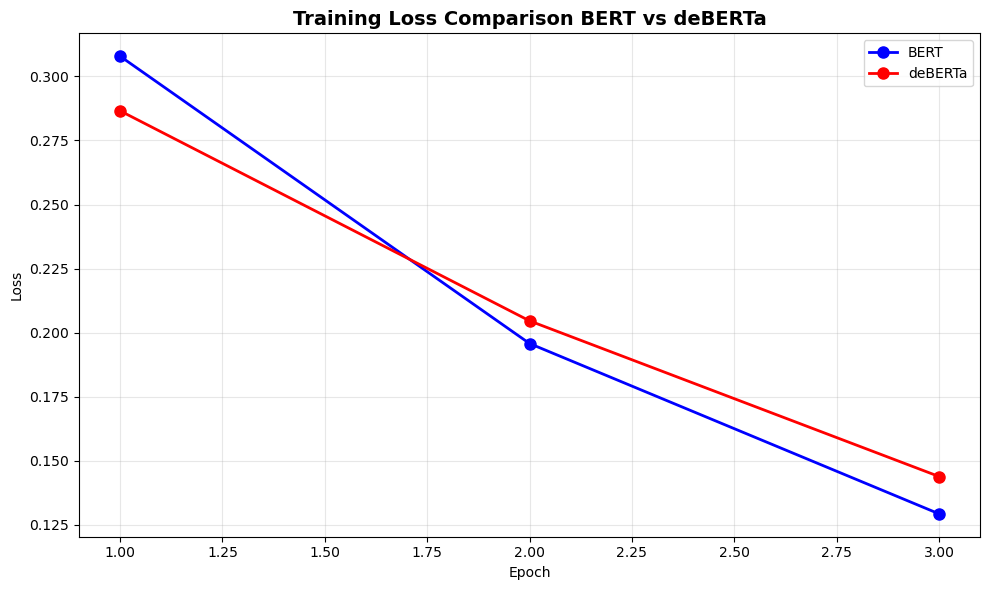

Chart 1 saved!
Generating Chart 2 Validation Accuracy...


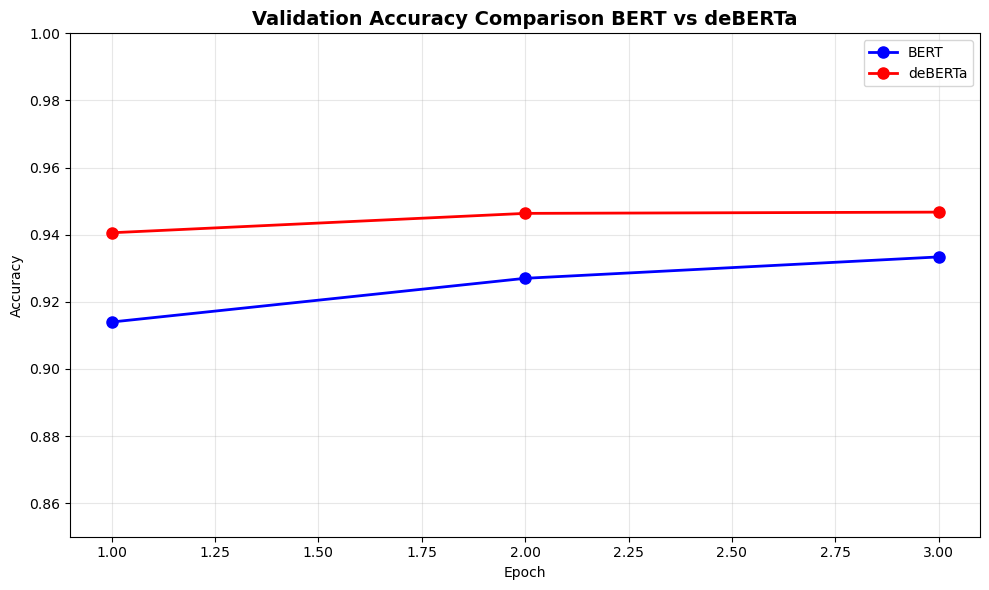

Chart 2 saved!
Generating Chart 3 All Metrics Comparison...


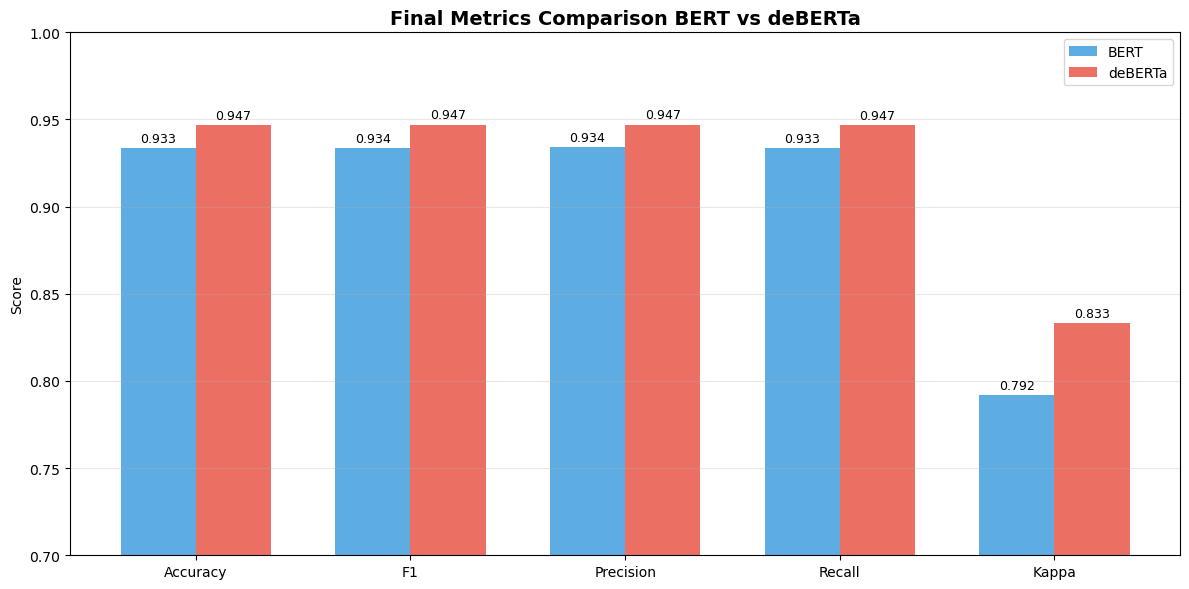

Chart 3 saved!
Generating Chart 4 F1 Score per Epoch...


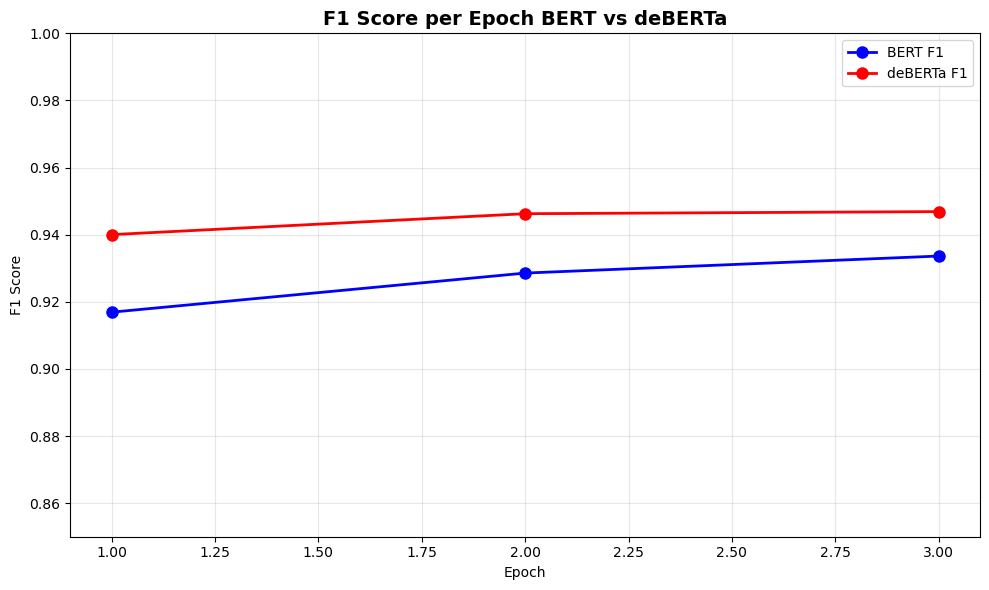

Chart 4 saved!
Generating Chart 5 Cohen Kappa per Epoch...


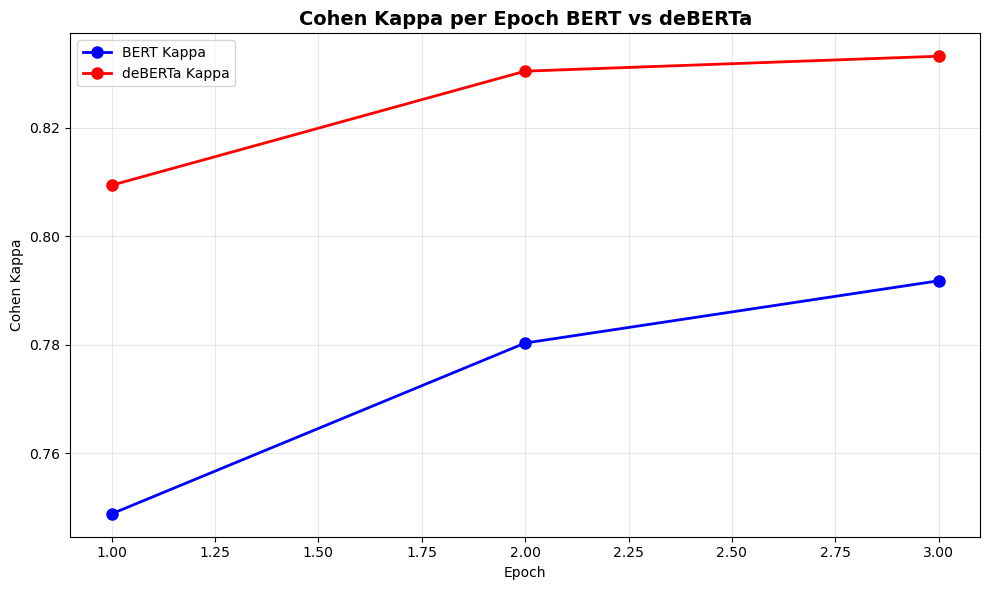

Chart 5 saved!
Generating Chart 6 Sentiment Distribution...


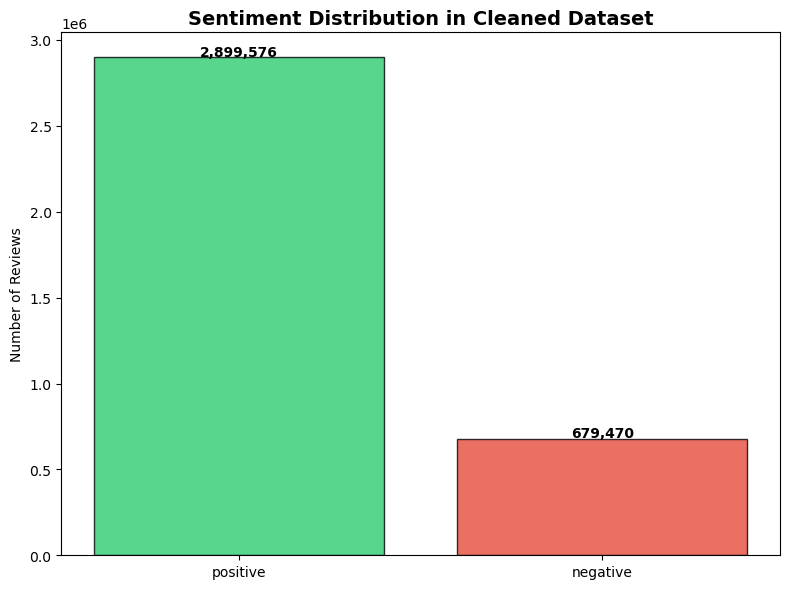

Chart 6 saved!
Generating Chart 7 Aspect Frequency...


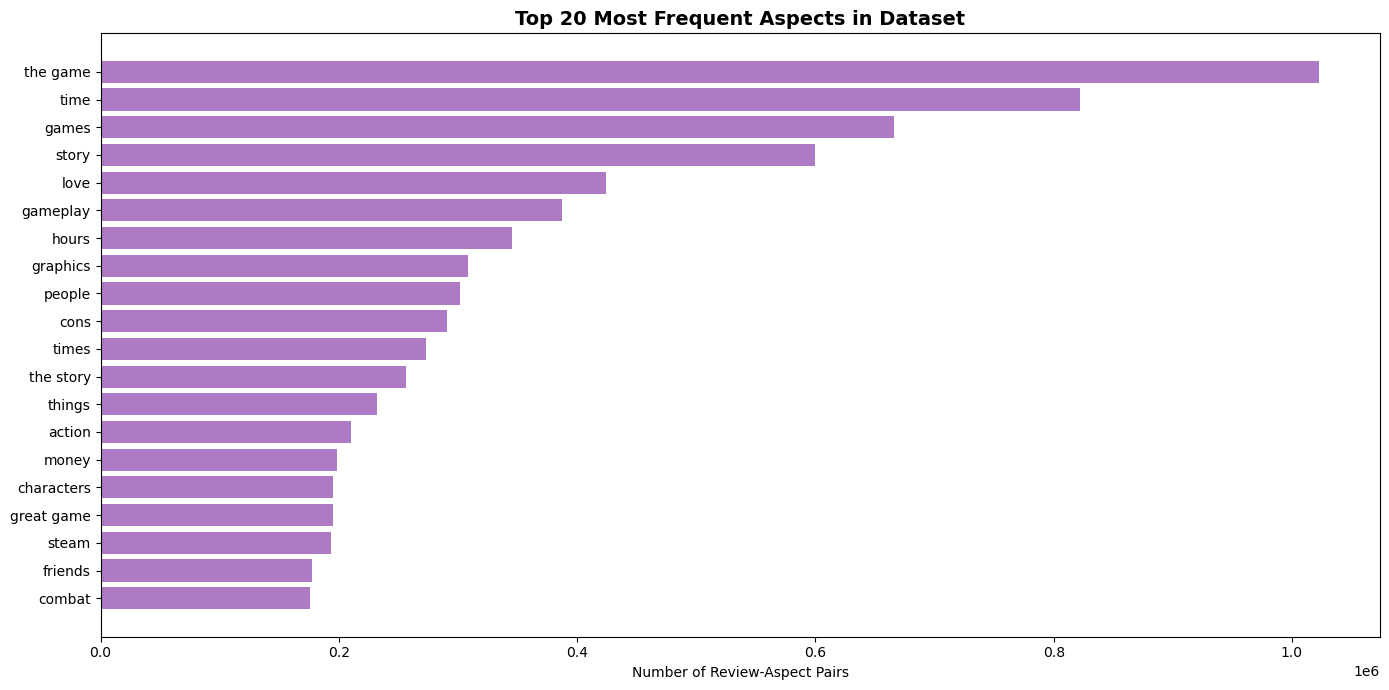

Chart 7 saved!
Generating Chart 8 Sentiment per Aspect...


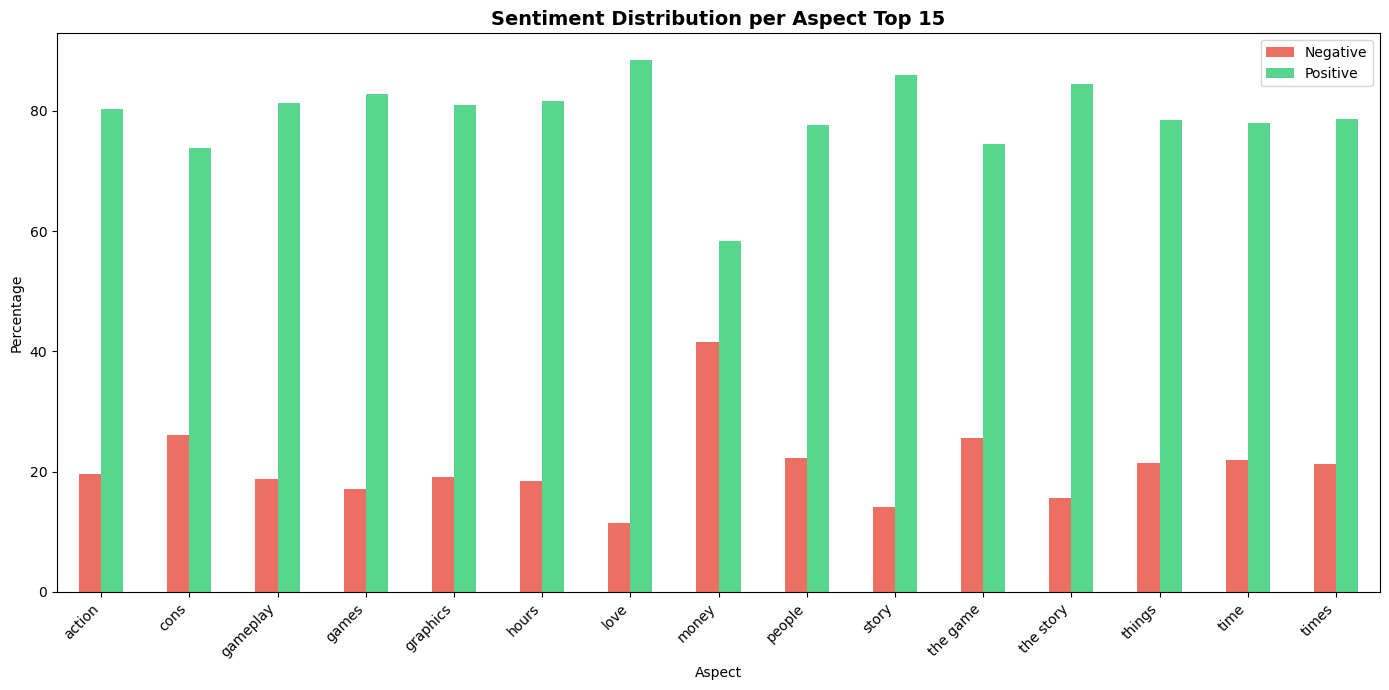

Chart 8 saved!

Loading test data for confusion matrices...

Loading BERT best model...


Getting predictions: 100%|██████████████████| 1250/1250 [06:07<00:00,  3.40it/s]


BERT predictions done!
BERT cleared from memory!

Loading deBERTa best model...


Getting predictions: 100%|██████████████████| 1250/1250 [09:03<00:00,  2.30it/s]


deBERTa predictions done!
deBERTa cleared from memory!
Generating Chart 9 BERT Confusion Matrix...


TypeError: ConfusionMatrixDisplay.plot() got an unexpected keyword argument 'colormap'

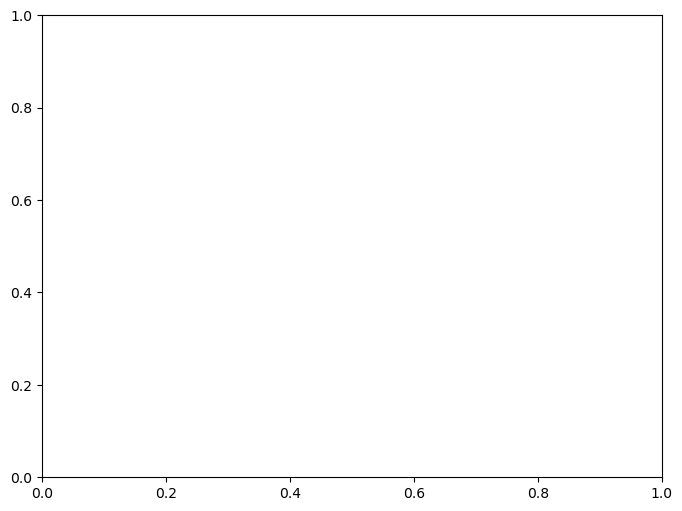

In [ ]:
# Block 19 All charts and visualisations for report

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import warnings
import gc
warnings.filterwarnings('ignore')

os.makedirs('report_charts', exist_ok=True)
print("Charts folder ready!")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# loading training histories
with open('bert_model/training_history.json', 'r') as f:
    bert_history = json.load(f)
with open('deberta_model/training_history.json', 'r') as f:
    deberta_history = json.load(f)

epochs = list(range(1, 4))

# Chart 1 Training loss comparison
print("\nGenerating Chart 1 Training Loss Comparison...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, bert_history['train_loss'], 'b-o', label='BERT', linewidth=2, markersize=8)
ax.plot(epochs, deberta_history['train_loss'], 'r-o', label='deBERTa', linewidth=2, markersize=8)
ax.set_title('Training Loss Comparison BERT vs deBERTa', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report_charts/01_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

# Chart 2 Validation accuracy comparison
print("Generating Chart 2 Validation Accuracy...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, bert_history['val_acc'], 'b-o', label='BERT', linewidth=2, markersize=8)
ax.plot(epochs, deberta_history['val_acc'], 'r-o', label='deBERTa', linewidth=2, markersize=8)
ax.set_title('Validation Accuracy Comparison BERT vs deBERTa', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report_charts/02_validation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

# Chart 3 All metrics comparison bar chart
print("Generating Chart 3 All Metrics Comparison...")
metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'Kappa']
bert_scores = [
    bert_history['val_acc'][-1],
    bert_history['val_f1'][-1],
    bert_history['val_precision'][-1],
    bert_history['val_recall'][-1],
    bert_history['val_kappa'][-1]
]
deberta_scores = [
    deberta_history['val_acc'][-1],
    deberta_history['val_f1'][-1],
    deberta_history['val_precision'][-1],
    deberta_history['val_recall'][-1],
    deberta_history['val_kappa'][-1]
]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, bert_scores, width, label='BERT', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, deberta_scores, width, label='deBERTa', color='#e74c3c', alpha=0.8)
ax.set_title('Final Metrics Comparison BERT vs deBERTa', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('report_charts/03_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# Chart 4 F1 score per epoch
print("Generating Chart 4 F1 Score per Epoch...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, bert_history['val_f1'], 'b-o', label='BERT F1', linewidth=2, markersize=8)
ax.plot(epochs, deberta_history['val_f1'], 'r-o', label='deBERTa F1', linewidth=2, markersize=8)
ax.set_title('F1 Score per Epoch BERT vs deBERTa', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report_charts/04_f1_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

# Chart 5 Cohen Kappa per epoch
print("Generating Chart 5 Cohen Kappa per Epoch...")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, bert_history['val_kappa'], 'b-o', label='BERT Kappa', linewidth=2, markersize=8)
ax.plot(epochs, deberta_history['val_kappa'], 'r-o', label='deBERTa Kappa', linewidth=2, markersize=8)
ax.set_title('Cohen Kappa per Epoch BERT vs deBERTa', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cohen Kappa')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report_charts/05_kappa_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

# Chart 6 Sentiment distribution 
print("Generating Chart 6 Sentiment Distribution...")
df = pd.read_csv('steam_reviews_cleaned.csv')
sentiment_counts = df['sentiment'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
              color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
ax.set_title('Sentiment Distribution in Cleaned Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Reviews')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'{bar.get_height():,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('report_charts/06_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

# Chart 7 Aspect frequency distribution
print("Generating Chart 7 Aspect Frequency...")
df_exploded = pd.read_csv('steam_reviews_exploded.csv')
aspect_counts = df_exploded['aspect'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(aspect_counts.index[::-1], aspect_counts.values[::-1], color='#9b59b6', alpha=0.8)
ax.set_title('Top 20 Most Frequent Aspects in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Review-Aspect Pairs')
plt.tight_layout()
plt.savefig('report_charts/07_aspect_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

# Chart 8 Sentiment per aspect 
print("Generating Chart 8 Sentiment per Aspect...")
top_aspects = df_exploded['aspect'].value_counts().head(15).index
aspect_sentiment = df_exploded[df_exploded['aspect'].isin(top_aspects)].groupby(
    ['aspect', 'sentiment']).size().unstack(fill_value=0)
aspect_sentiment_pct = aspect_sentiment.div(aspect_sentiment.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(14, 7))
aspect_sentiment_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], alpha=0.8)
ax.set_title('Sentiment Distribution per Aspect Top 15', fontsize=14, fontweight='bold')
ax.set_xlabel('Aspect')
ax.set_ylabel('Percentage')
ax.legend(['Negative', 'Positive'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('report_charts/08_sentiment_per_aspect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")

Predictions loaded!
Top aspects: ['the game', 'time', 'games', 'story', 'love', 'gameplay', 'hours', 'graphics', 'people', 'cons']
Generating Chart 9...


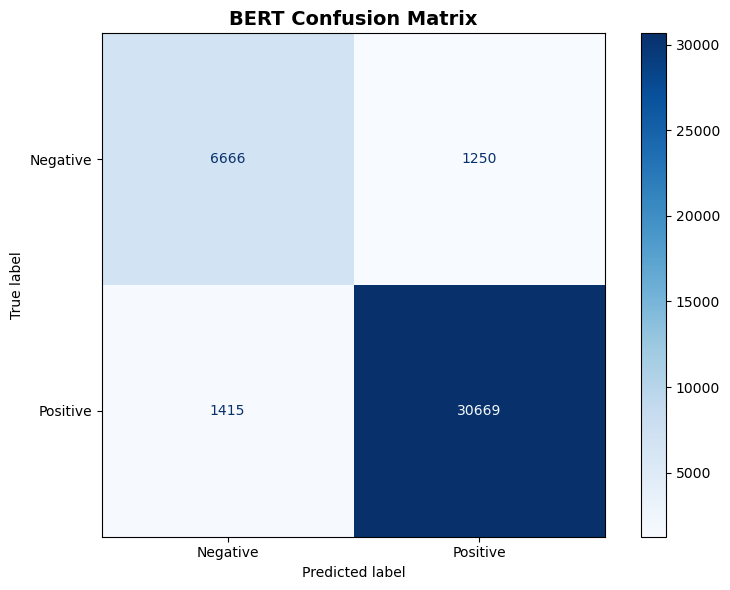

Chart 9 saved!
Generating Chart 10...


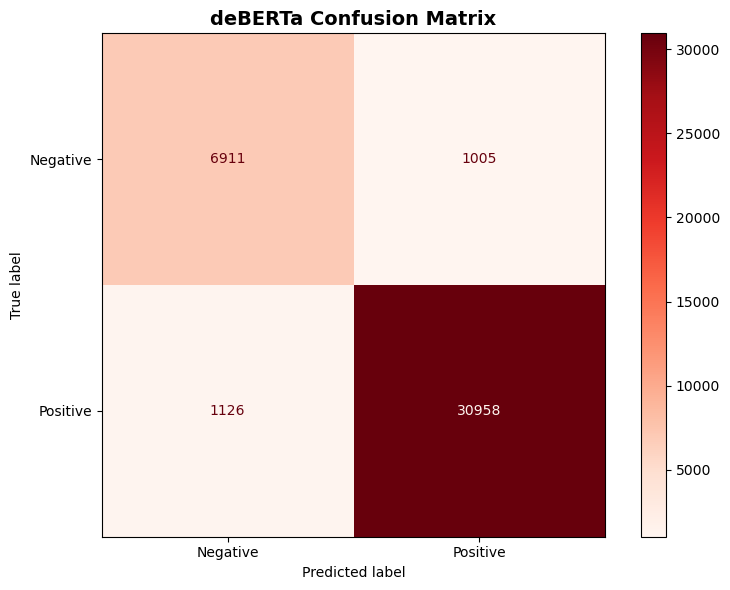

Chart 10 saved!
Generating Chart 11 per aspect confusion matrices...


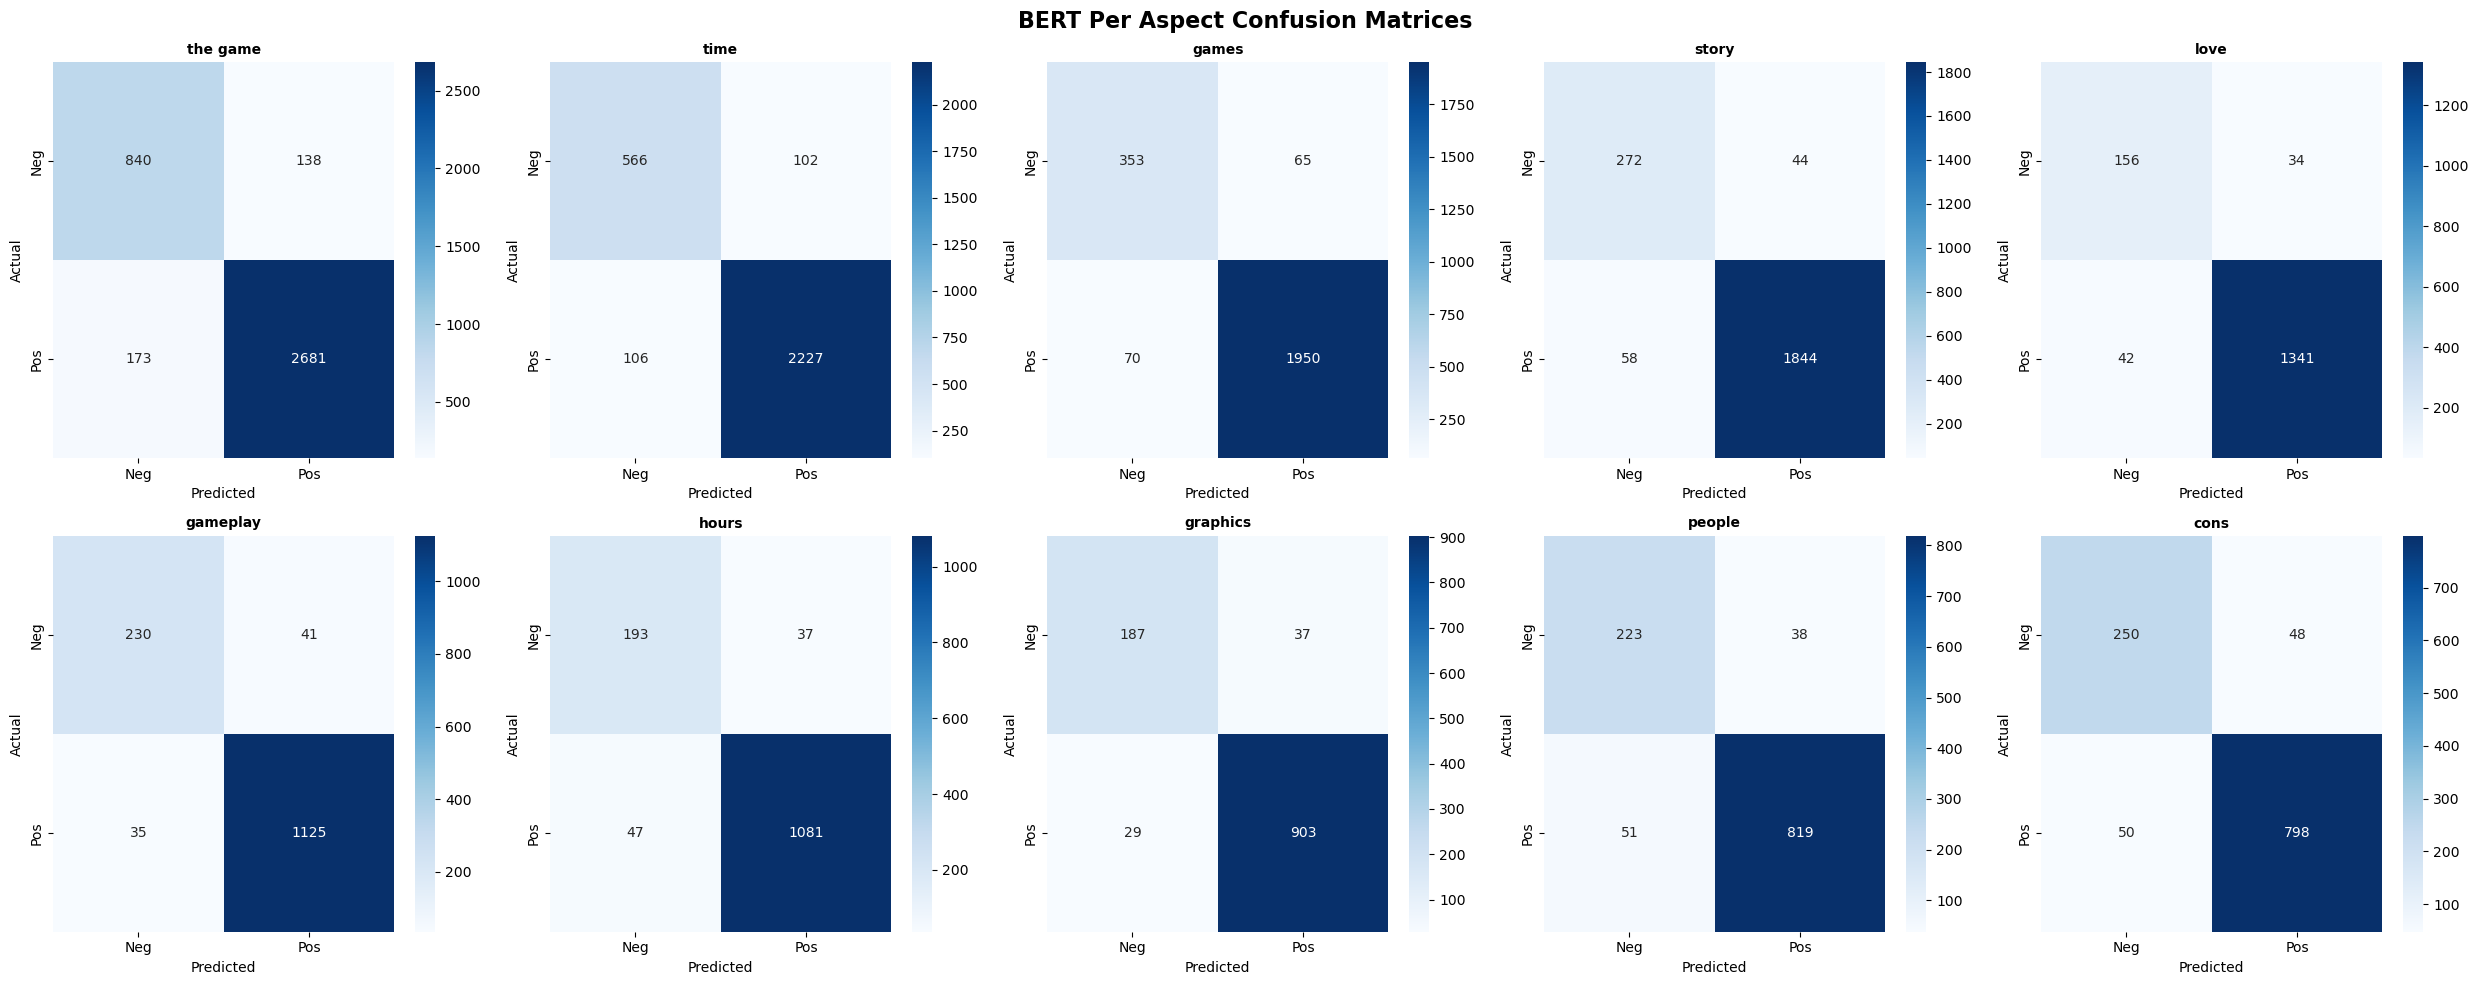

Chart 11 BERT saved!


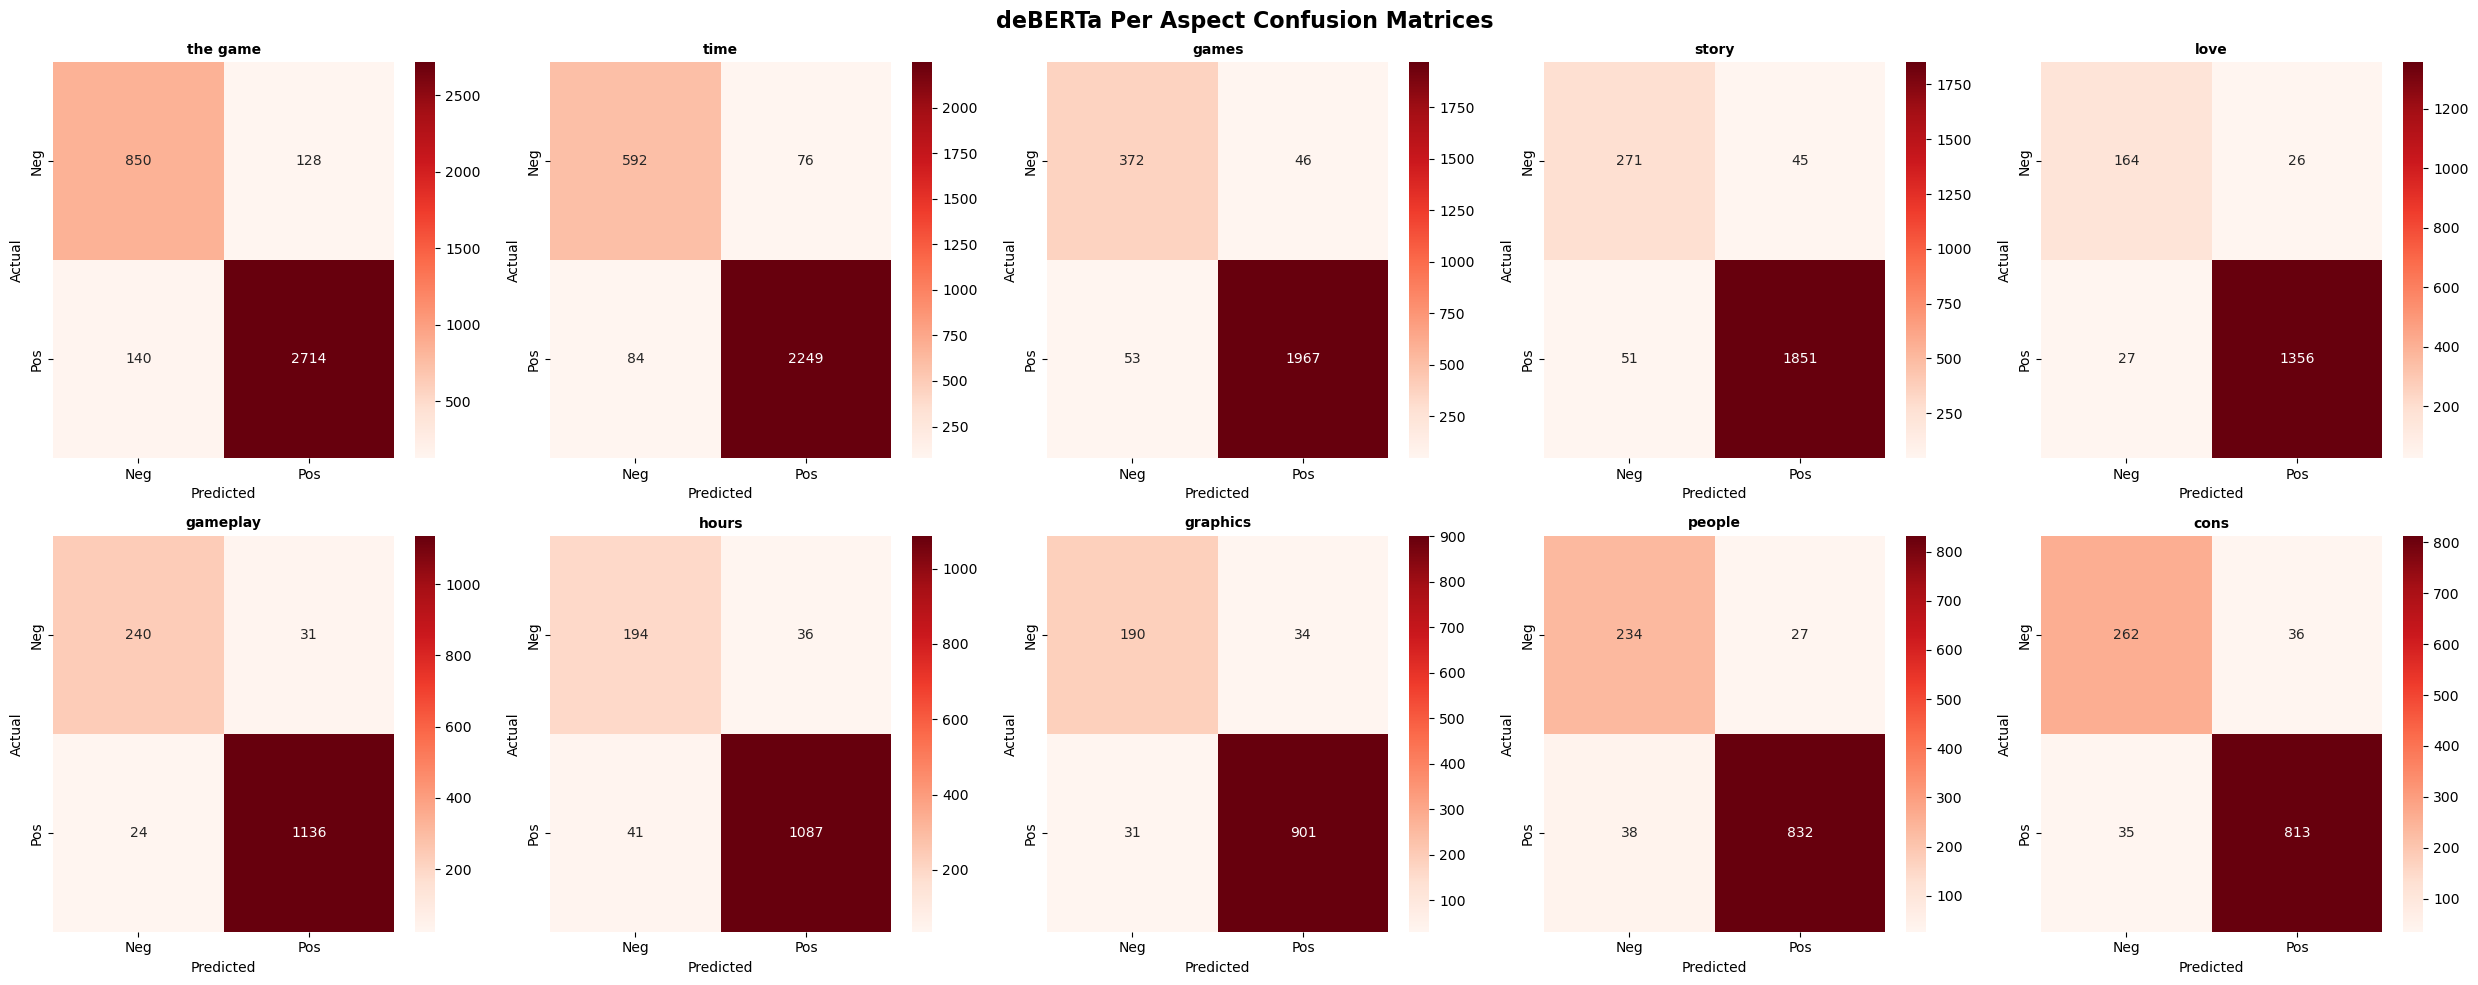

Chart 11 deBERTa saved!
Generating Chart 12...


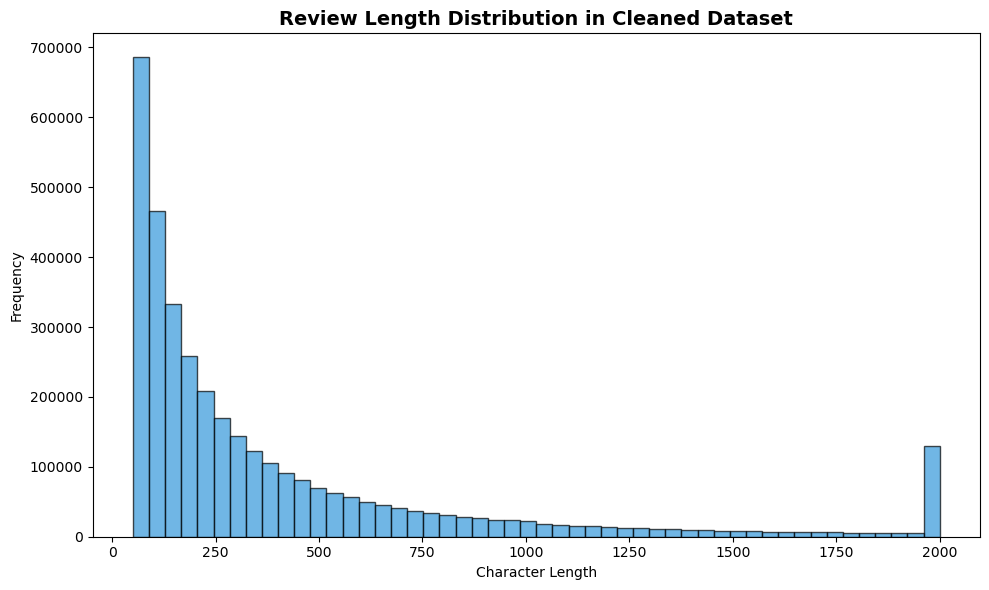

Chart 12 saved!

All charts done!


In [6]:
# Generating confusion matrices from saved predictions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs('report_charts', exist_ok=True)

bert_labels = np.load('bert_labels.npy')
bert_preds = np.load('bert_preds.npy')
deberta_labels = np.load('deberta_labels.npy')
deberta_preds = np.load('deberta_preds.npy')
print("Predictions loaded!")

test_df = pd.read_csv('test.csv')
test_sample, _ = train_test_split(
    test_df,
    train_size=40000,
    random_state=42,
    stratify=test_df['label']
)

df_exploded = pd.read_csv('steam_reviews_exploded.csv')
top_aspects_list = df_exploded['aspect'].value_counts().head(10).index.tolist()
print(f"Top aspects: {top_aspects_list}")

# Chart 9 BERT overall confusion matrix
print("Generating Chart 9...")
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(bert_labels, bert_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('BERT Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('report_charts/09_bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved!")

# Chart 10 deBERTa overall confusion matrix
print("Generating Chart 10...")
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(deberta_labels, deberta_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Reds')
ax.set_title('deBERTa Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('report_charts/10_deberta_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved!")

# Chart 11 per aspect confusion matrices
print("Generating Chart 11 per aspect confusion matrices...")
for model_name, labels_arr, preds_arr in [('BERT', bert_labels, bert_preds),
                                           ('deBERTa', deberta_labels, deberta_preds)]:
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    for idx, aspect in enumerate(top_aspects_list):
        aspect_mask = test_sample['aspect'].values == aspect
        if aspect_mask.sum() == 0:
            continue
        aspect_labels = labels_arr[aspect_mask]
        aspect_preds = preds_arr[aspect_mask]
        cm = confusion_matrix(aspect_labels, aspect_preds, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d',
                    cmap='Blues' if model_name == 'BERT' else 'Reds',
                    ax=axes[idx],
                    xticklabels=['Neg', 'Pos'],
                    yticklabels=['Neg', 'Pos'])
        axes[idx].set_title(f'{aspect}', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    fig.suptitle(f'{model_name} Per Aspect Confusion Matrices', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'report_charts/11_{model_name.lower()}_per_aspect_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart 11 {model_name} saved!")

# Chart 12 review length distribution
print("Generating Chart 12...")
df = pd.read_csv('steam_reviews_cleaned.csv')
df['review_length'] = df['review_text'].str.len()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['review_length'].clip(upper=2000), bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax.set_title('Review Length Distribution in Cleaned Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('report_charts/12_review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 12 saved!")

print("\nAll charts done!")

Using device: mps
Loading BERT model for explainability...
Model loaded!
Generating LIME explanations...
Explaining review 1/8...
Explaining review 2/8...
Explaining review 3/8...
Explaining review 4/8...
Explaining review 5/8...
Explaining review 6/8...
Explaining review 7/8...
Explaining review 8/8...


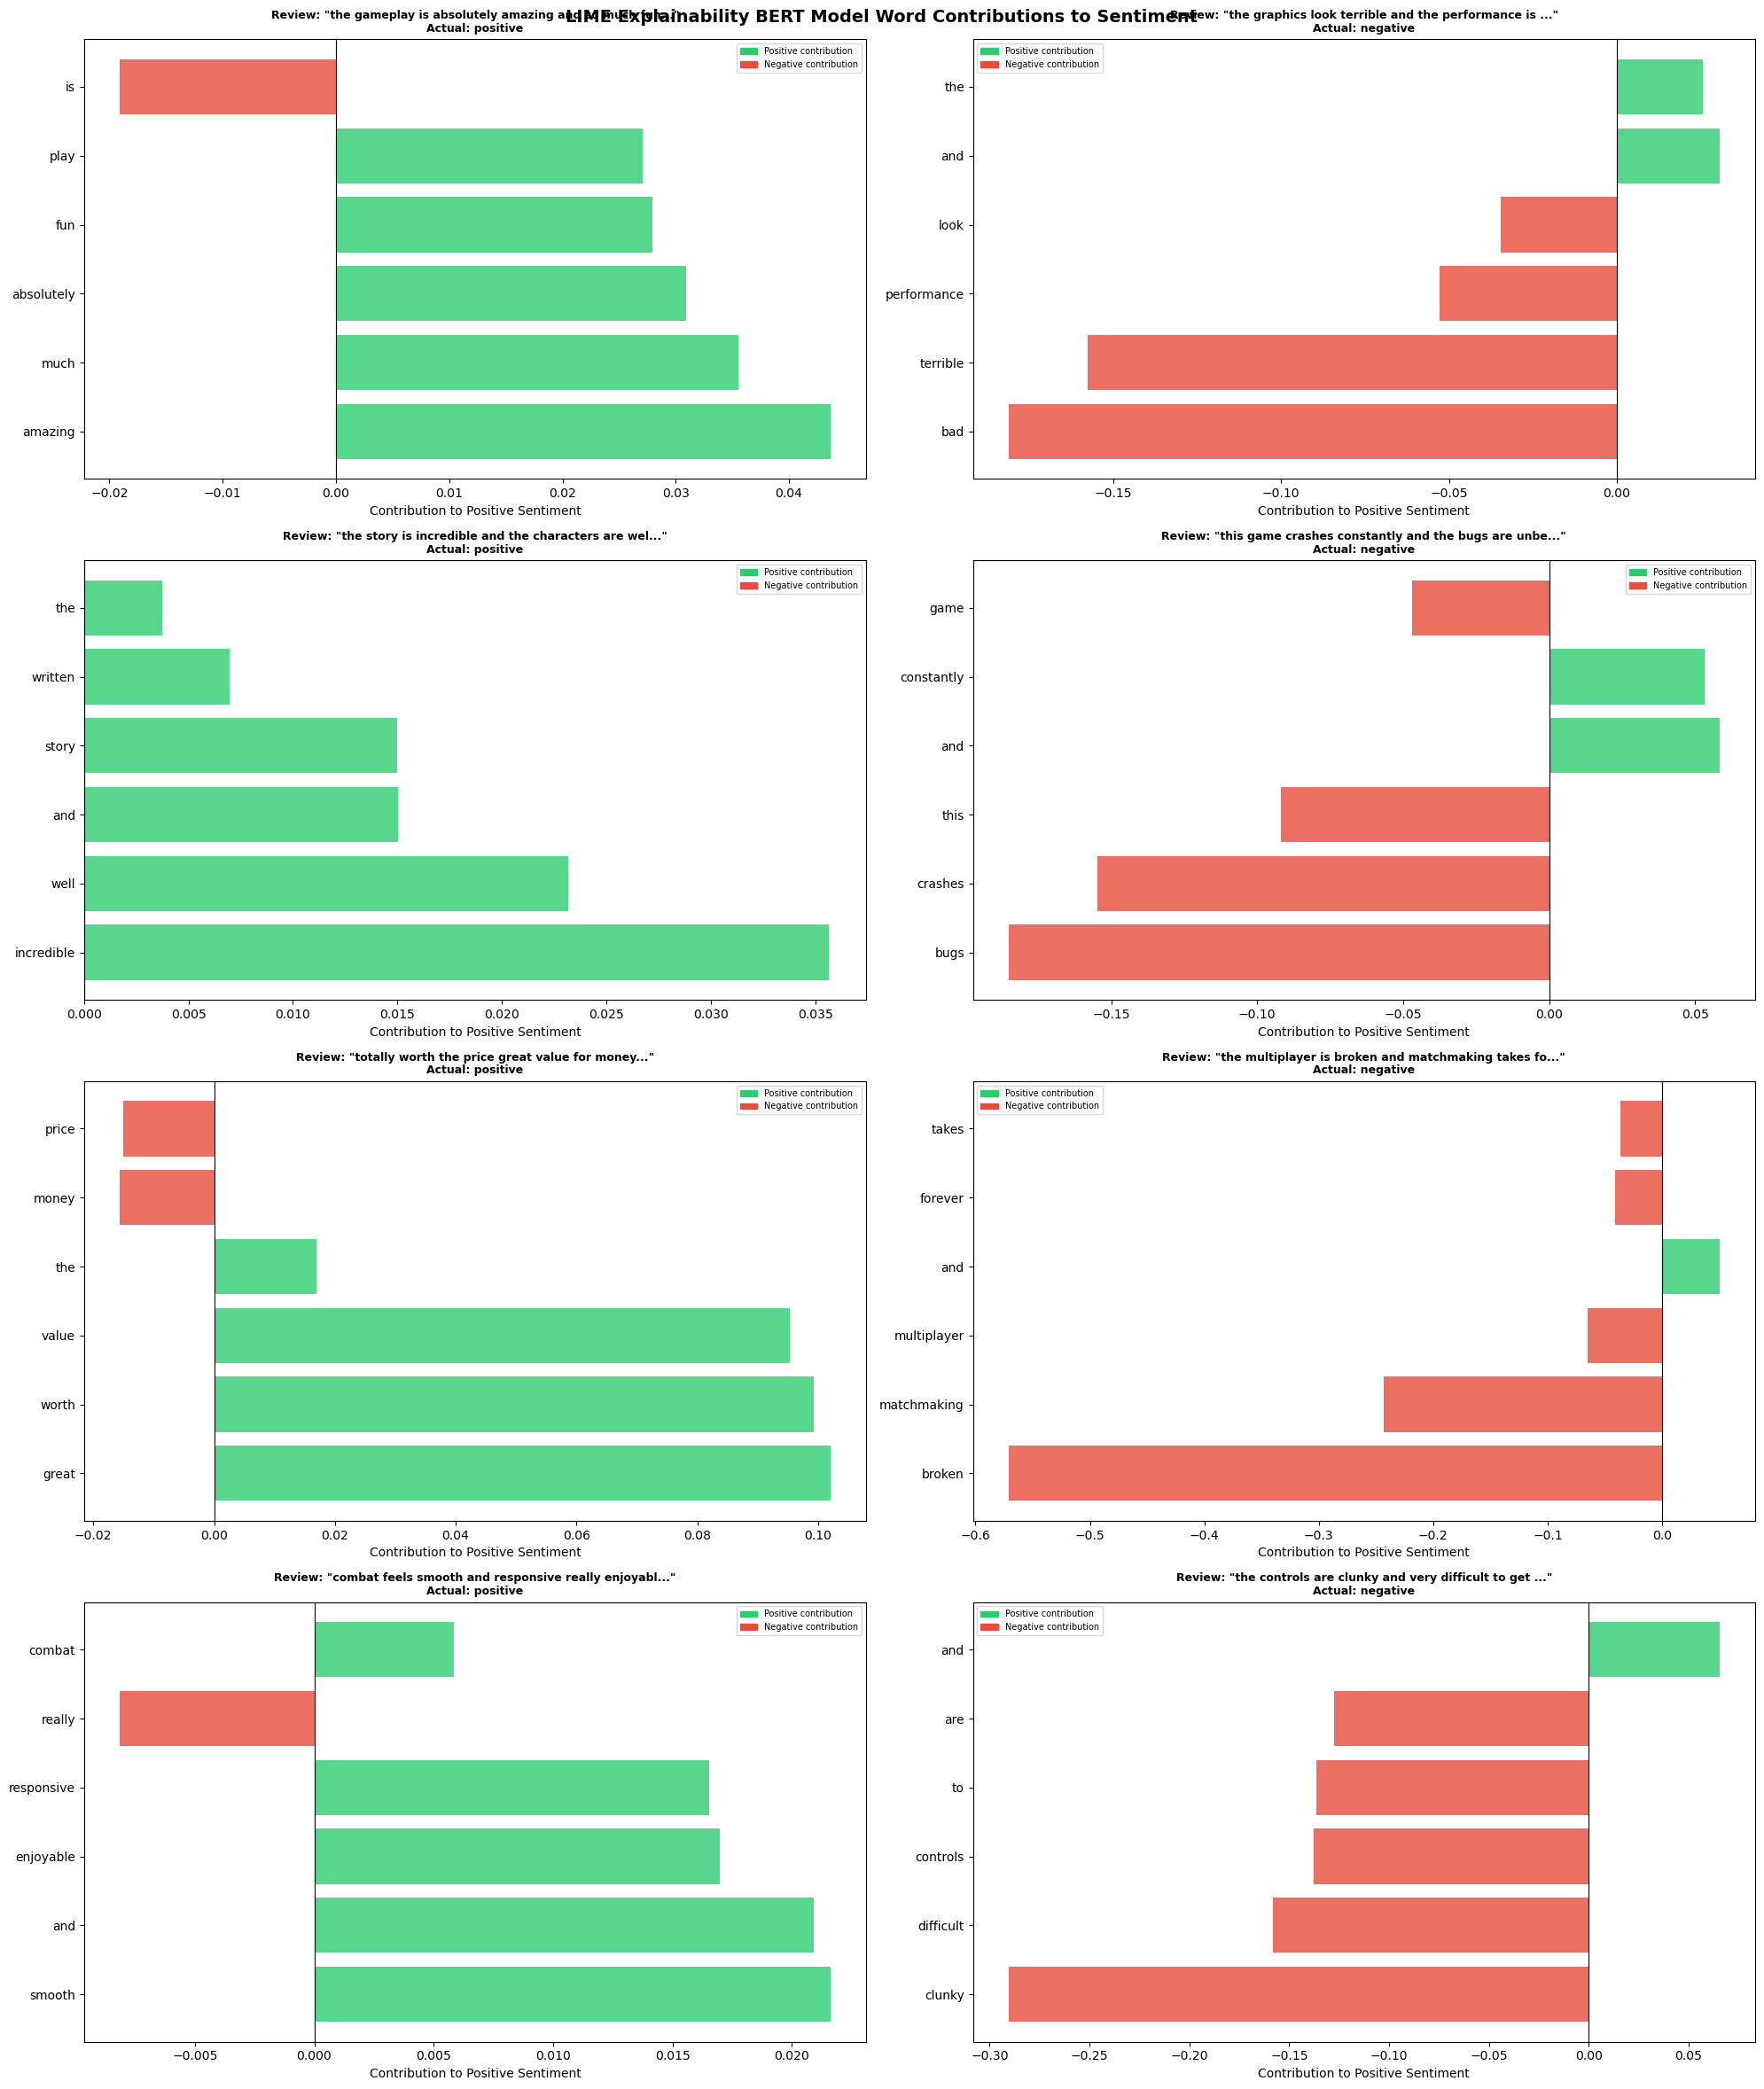

Chart 13 saved: LIME Explainability!
Memory cleared!

Block 20 completed!


In [7]:
# Block 20 LIME explainability showing why the model made each prediction

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import BertTokenizer, BertForSequenceClassification
from lime.lime_text import LimeTextExplainer
import warnings
import os
import gc
import sys
warnings.filterwarnings('ignore')

# install lime
os.system(f'{sys.executable} -m pip install lime -q')
from lime.lime_text import LimeTextExplainer

os.makedirs('report_charts', exist_ok=True)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# load BERT best model
print("Loading BERT model for explainability...")
bert_tokenizer = BertTokenizer.from_pretrained('bert_model/best_model')
bert_model = BertForSequenceClassification.from_pretrained('bert_model/best_model')
bert_model = bert_model.to(device)
bert_model.eval()
print("Model loaded!")

# prediction function for LIME
def predict_proba(texts):
    encodings = bert_tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)
    with torch.no_grad():
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    return probs

# sample reviews to explain covering different aspects
sample_reviews = [
    "the gameplay is absolutely amazing and so much fun to play",
    "the graphics look terrible and the performance is really bad",
    "the story is incredible and the characters are well written",
    "this game crashes constantly and the bugs are unbearable",
    "totally worth the price great value for money",
    "the multiplayer is broken and matchmaking takes forever",
    "combat feels smooth and responsive really enjoyable",
    "the controls are clunky and very difficult to get used to"
]

sample_labels = ['positive', 'negative', 'positive', 'negative',
                 'positive', 'negative', 'positive', 'negative']

# LIME explainer
explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

print("Generating LIME explanations...")
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.flatten()

for idx, (review, label) in enumerate(zip(sample_reviews, sample_labels)):
    print(f"Explaining review {idx+1}/{len(sample_reviews)}...")
    
    exp = explainer.explain_instance(
        review,
        predict_proba,
        num_features=6,
        num_samples=100
    )
    
    # get word contributions
    word_weights = exp.as_list()
    words = [w[0] for w in word_weights]
    weights = [w[1] for w in word_weights]
    colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]
    
    axes[idx].barh(words, weights, color=colors, alpha=0.8)
    axes[idx].set_title(f'Review: "{review[:50]}..."\nActual: {label}', 
                        fontsize=9, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linewidth=0.8)
    axes[idx].set_xlabel('Contribution to Positive Sentiment')
    
    positive_patch = mpatches.Patch(color='#2ecc71', label='Positive contribution')
    negative_patch = mpatches.Patch(color='#e74c3c', label='Negative contribution')
    axes[idx].legend(handles=[positive_patch, negative_patch], fontsize=7)

plt.suptitle('LIME Explainability BERT Model Word Contributions to Sentiment', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('report_charts/13_lime_explainability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 13 saved: LIME Explainability!")

# clean up memory
del bert_model
del bert_tokenizer
gc.collect()
torch.mps.empty_cache()
print("Memory cleared!")
print("\nBlock 20 completed!")

In [9]:
import sys
!{sys.executable} -m pip install streamlit

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 16.1 MB/s  0:00:00 13.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 kB 13.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.7 MB/s  0:00:0021.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [streamlit]237m━━ 18/19 [streamlit]


In [13]:
# Block 21 Launching the Streamlit chatbot

import subprocess
import sys
import os

os.chdir(os.path.expanduser('~/anaconda_projects/25229cf8-816f-4b3f-9597-4d3d1503b8ac'))

print("Launching Streamlit app...")
print("Once launched open your browser and go to: http://localhost:8501")

subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py'])

Launching Streamlit app...
Once launched open your browser and go to: http://localhost:8501


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


<Popen: returncode: None args: ['/opt/anaconda3/envs/anaconda-ml-ai/bin/pyth...>